In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.signal as sc
import xarray as xr
np.seterr(divide='ignore')
import numpy.ma as ma

In [ ]:
def plot_C_all_Deltas(C_in, c_var, C_sq_1_beta, z, z_i, labels_in, title, plot_dir, case='BOMEX', t='14400', C_type = 'C', set_x_axis=None, IC_label = False):

    clock_time_int = 05.30 + int(t)/(60*60)
    clock_time = str(clock_time_int)+'0L'

    colours = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple',
               'tab:cyan', 'tab:gray', 'tab:brown', 'tab:olive', 'tab:pink']

    fig, ax = plt.subplots(nrows=1, ncols=1, sharey=False, figsize=(4,6))

    fig.tight_layout(pad=0.5)

    if c_var == 'Cs':
        c_var_label = '$C_{s}$'
    elif c_var == 'Cth':
        c_var_label = '$C_{\\theta}$'
    elif c_var == 'Cth_v':
        c_var_label = '$C_{\\theta_v}$'
    elif c_var == 'Cth_e':
        c_var_label = '$C_{\\theta_e}$'
    elif c_var == 'Cth_L':
        c_var_label = '$C_{\\theta_L}$'
    elif c_var == 'Cqt':
        c_var_label = '$C_{q_t}$'
    elif c_var == 'Cqv':
        c_var_label = '$C_{q_v}$'

    if C_type == 'C':
        if case == 'BOMEX':
            ax.set_xlabel(c_var_label+f' {title}', fontsize=16)

        else:
            ax.set_xlabel(c_var_label+f' {title} at {clock_time}', fontsize=16)


        ax.plot(get_Cs(C_in[0,:]/(C_sq_1_beta[0,:]/C_in[0,:])),
         z/z_i, label='$\\widehat{\\bar{\\Delta}} = 2\\Delta}$ ($\\beta$)')

    else:
        if case == 'BOMEX':
            ax.set_xlabel(c_var_label+'$^2$'+f' {title}', fontsize=16)

        else:
            ax.set_xlabel(c_var_label+'$^2$'+f' {title} at {clock_time}', fontsize=16)


        ax.plot(C_in[0,:]/(C_sq_1_beta[0,:]/C_in[0,:]),
         z/z_i, label='$\\widehat{\\bar{\\Delta}} = 2\\Delta} (\\beta)$')


    for it in range(len(C_in[:,0])):
        if C_type == 'C':
            ax.plot(get_Cs(C_in[it,:]), z/z_i, color=colours[it+1], label='$\\widehat{\\bar{\\Delta}} = $'+labels_in[it])

        else:
            ax.plot(C_in[it,:], z/z_i, color=colours[it+1], label='$\\widehat{\\bar{\\Delta}} = $'+labels_in[it])


    # else:
    #     ax[0].set_xlabel('$C^2_{s}$', fontsize=16)
    #     ax[1].set_xlabel('$C^2_{\\theta}$', fontsize=16)
    #     ax[2].set_xlabel('$C^2_{qt}$', fontsize=16)
    if IC_label == False:
        ax.legend(fontsize=13, loc='upper right')

    else:
        ax.legend(fontsize=13, loc='upper left')


    plt.tight_layout()

    set_left, set_right = ax.set_xlim()

    if set_x_axis is not None:
        set_right = set_x_axis[1]
        set_left = set_x_axis[0]


    print('for all Delta profs, min is = ', set_left, 'max is =', set_right)

    ax.set_xlim(right = set_right, left = set_left)

    ax.set_ylim(bottom=0)
    ax.set_ylabel("z/z$_{ML}$ (z$_{ML}$ = "+ str(z_i) + "m)", fontsize=16)

    plt.savefig(plot_dir + f'{case}_{t}_{c_var}_{C_type}_{title}_all_Delta_prof_scaled_zn.pdf', bbox_inches='tight')
    plt.savefig(plot_dir + f'{case}_{t}_{c_var}_{C_type}_{title}_all_Delta_prof_scaled_zn.png', bbox_inches='tight')
    plt.show()

    plt.close()

In [ ]:
set_labels = ['4$\\Delta$', '8$\\Delta$', '16$\\Delta$', '32$\\Delta$', '64$\\Delta$', '128$\\Delta$']
deltas = ['4D', '8D', '16D', '32D', '64D', '128D']

In [ ]:

arm_path_th_L = 'C:/Users/si818415/Documents/code/LES_analysis/data/C_profs_th_L/ARM/'
bomex_path_th_L = 'C:/Users/si818415/Documents/code/LES_analysis/data/C_profs_th_L/BOMEX/'

arm_path_th = 'C:/Users/si818415/Documents/code/LES_analysis/data/C_profs_th/ARM/'
bomex_path_th = 'C:/Users/si818415/Documents/code/LES_analysis/data/C_profs_th/BOMEX/'

arm_path_th_v = 'C:/Users/si818415/Documents/code/LES_analysis/data/th_v/ARM/'
bomex_path_th_v = 'C:/Users/si818415/Documents/code/LES_analysis/data/th_v/BOMEX/'

bomex_path_th_e = 'C:/Users/si818415/Documents/code/LES_analysis/data/th_e/BOMEX/'


plot_dir_BOMEX = 'C:/Users/si818415/Documents/plots/C_profs_ALL/BOMEX/C_profs/'
plot_dir_ARM = 'C:/Users/si818415/Documents/plots/C_profs_ALL/ARM/C_profs/'
plot_dir_all = 'C:/Users/si818415/Documents/plots/C_profs_ALL/C_profs/'

path='C:/Users/si818415/Documents/code/LES_analysis/data/'

os.makedirs(plot_dir_BOMEX, exist_ok = True)
os.makedirs(plot_dir_ARM, exist_ok = True)
os.makedirs(plot_dir_all, exist_ok = True)

In [ ]:
def calc_d_hat(delta):
    delta_metres = np.zeros(7)
    for i in range(7):
        delta_metres[i] = delta * 2 ** i + 1
    return delta_metres

In [96]:
def clock(nt):
    t = ARM_times[nt]
    clock_time_int = 05.30 + int(t)/(60*60)
    clock_time = str(clock_time_int)+'0L'
    return clock_time

def plot_C_all_partit(C_in, c_var, z, z_i, labels_in, plot_dir, case='BOMEX', C_type = 'C', set_x_axis=None, IC_label = False):

    colours = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple',
               'tab:cyan', 'tab:gray', 'tab:brown', 'tab:olive', 'tab:pink']


    if c_var == 'Cs':
        c_var_label = '$C_{s}$'
    elif c_var == 'Cth':
        c_var_label = '$C_{\\theta}$'
    elif c_var == 'Cth_v':
        c_var_label = '$C_{\\theta_v}$'
    elif c_var == 'Cth_e':
        c_var_label = '$C_{\\theta_e}$'
    elif c_var == 'Cth_L':
        c_var_label = '$C_{\\theta_L}$'
    elif c_var == 'Cqt':
        c_var_label = '$C_{q_t}$'
    elif c_var == 'Cqv':
        c_var_label = '$C_{q_v}$'



    if case == 'BOMEX':
        fig, ax = plt.subplots(nrows=1, ncols=1, sharey=False, figsize=(5,6))
        fig.tight_layout(pad=0.5)
        for it in range(len(C_in[:,0])):
            if C_type == 'C':
                ax.plot(get_Cs(C_in[it,:]), z/z_i, color=colours[it+1], label=labels_in[it])

            else:
                ax.plot(C_in[it,:], z/z_i, color=colours[it+1], label=labels_in[it])

            if IC_label == False:
                ax.legend(fontsize=13, loc='upper right')

            else:
                ax.legend(fontsize=13, loc='upper left')

        if set_x_axis is not None:
            ax.set_xlim(right = set_x_axis[1], left = set_x_axis[0])
        ax.set_xlabel(c_var_label+'$^2$', fontsize=16)

        ax.set_ylim(bottom=0)
        ax.set_ylabel("z/z$_{ML}$ (z$_{ML}$ = "+ str(z_i) + "m)", fontsize=16)

    else:
        fig, ax = plt.subplots(nrows=1, ncols=4, sharey=False, figsize=(20,6))
        fig.tight_layout(pad=0.5)
        for A_nt in range(4):
            for it in range(len(C_in[0,:,0])):
                if C_type == 'C':
                    ax[A_nt].plot(get_Cs(C_in[A_nt, it,:]), z/z_i[A_nt], color=colours[it+1], label=labels_in[it])

                else:
                    ax[A_nt].plot(C_in[A_nt, it,:], z/z_i[A_nt], color=colours[it+1], label=labels_in[it])

                if IC_label == False:
                    ax[A_nt].legend(fontsize=13, loc='upper right')

                else:
                    ax[A_nt].legend(fontsize=13, loc='upper left')

            if set_x_axis is not None:
                ax[A_nt].set_xlim(right = set_x_axis[1], left = set_x_axis[0])
            clock_time = clock(A_nt)
            ax[A_nt].set_xlabel(c_var_label+f' at {clock_time}', fontsize=16)

            ax[A_nt].set_ylim(bottom=0)
            ax[A_nt].set_ylabel("z/z$_{ML}$ (z$_{ML}$ = "+ str(z_i[A_nt]) + "m)", fontsize=16)


    plt.tight_layout()

    plt.savefig(plot_dir + f'{case}_{c_var}_{C_type}_all_partit_prof_scaled_zn.pdf', bbox_inches='tight')
    plt.savefig(plot_dir + f'{case}_{c_var}_{C_type}_all_partit_prof_scaled_zn.png', bbox_inches='tight')
    plt.show()

    plt.close()

In [ ]:
dx_BOMEX=20
z_BOMEX = np.arange(0, 3020, 20)
z_i_BOMEX = 430 #1120
D_m_BOMEX = calc_d_hat(20)


dx_ARM=25
z_ARM = np.arange(0, 4410, 10)
z_i_ARM = [795, 955, 1095, 1255]
ARM_times = ['18000', '25200', '32400', '39600']
D_m_ARM = calc_d_hat(25)

In [ ]:
Cs_sq_BOMEX_0 = np.load(bomex_path_th_L+f'C_sq_cond_14400_0.npy')[0,...]
Cs_sq_BOMEX_1 = np.load(bomex_path_th_L+f'C_sq_cond_14400_1.npy')[0,...]

Cs_sq_ARM_18000_0 = np.load(arm_path_th_L+f'C_sq_cond_18000_0.npy')[0,...]
Cs_sq_ARM_25200_0 = np.load(arm_path_th_L+f'C_sq_cond_25200_0.npy')[0,...]
Cs_sq_ARM_32400_0 = np.load(arm_path_th_L+f'C_sq_cond_32400_0.npy')[0,...]
Cs_sq_ARM_39600_0 = np.load(arm_path_th_L+f'C_sq_cond_39600_0.npy')[0,...]

Cs_sq_ARM_18000_1 = np.load(arm_path_th_L+f'C_sq_cond_18000_1.npy')[0,...]
Cs_sq_ARM_25200_1 = np.load(arm_path_th_L+f'C_sq_cond_25200_1.npy')[0,...]
Cs_sq_ARM_32400_1 = np.load(arm_path_th_L+f'C_sq_cond_32400_1.npy')[0,...]
Cs_sq_ARM_39600_1 = np.load(arm_path_th_L+f'C_sq_cond_39600_1.npy')[0,...]


Cs_sq_ARM_0 = [Cs_sq_ARM_18000_0, Cs_sq_ARM_25200_0, Cs_sq_ARM_32400_0, Cs_sq_ARM_39600_0]
Cs_sq_ARM_1 = [Cs_sq_ARM_18000_1, Cs_sq_ARM_25200_1, Cs_sq_ARM_32400_1, Cs_sq_ARM_39600_1]

Cs_sq_ARM_0 = np.reshape(Cs_sq_ARM_0, ( 4, len(Cs_sq_ARM_18000_0[:, 0,0]), len(Cs_sq_ARM_18000_0[0,:,0]), len(Cs_sq_ARM_18000_0[0,0,:])  ) )
Cs_sq_ARM_1 = np.reshape(Cs_sq_ARM_1, ( 4, len(Cs_sq_ARM_18000_1[:, 0,0]), len(Cs_sq_ARM_18000_1[0,:,0]), len(Cs_sq_ARM_18000_1[0,0,:])  ) )



Cth_L_sq_BOMEX_0 = np.load(bomex_path_th_L+f'C_sq_cond_14400_0.npy')[1,...]
Cth_L_sq_BOMEX_1 = np.load(bomex_path_th_L+f'C_sq_cond_14400_1.npy')[1,...]

Cth_L_sq_ARM_18000_0 = np.load(arm_path_th_L+f'C_sq_cond_18000_0.npy')[1,...]
Cth_L_sq_ARM_25200_0 = np.load(arm_path_th_L+f'C_sq_cond_25200_0.npy')[1,...]
Cth_L_sq_ARM_32400_0 = np.load(arm_path_th_L+f'C_sq_cond_32400_0.npy')[1,...]
Cth_L_sq_ARM_39600_0 = np.load(arm_path_th_L+f'C_sq_cond_39600_0.npy')[1,...]

Cth_L_sq_ARM_18000_1 = np.load(arm_path_th_L+f'C_sq_cond_18000_1.npy')[1,...]
Cth_L_sq_ARM_25200_1 = np.load(arm_path_th_L+f'C_sq_cond_25200_1.npy')[1,...]
Cth_L_sq_ARM_32400_1 = np.load(arm_path_th_L+f'C_sq_cond_32400_1.npy')[1,...]
Cth_L_sq_ARM_39600_1 = np.load(arm_path_th_L+f'C_sq_cond_39600_1.npy')[1,...]


Cth_L_sq_ARM_0 = [Cth_L_sq_ARM_18000_0, Cth_L_sq_ARM_25200_0, Cth_L_sq_ARM_32400_0, Cth_L_sq_ARM_39600_0]
Cth_L_sq_ARM_1 = [Cth_L_sq_ARM_18000_1, Cth_L_sq_ARM_25200_1, Cth_L_sq_ARM_32400_1, Cth_L_sq_ARM_39600_1]

Cth_L_sq_ARM_0 = np.reshape(Cth_L_sq_ARM_0, ( 4, len(Cs_sq_ARM_18000_0[:, 0,0]), len(Cs_sq_ARM_18000_0[0,:,0]), len(Cs_sq_ARM_18000_0[0,0,:])  ) )
Cth_L_sq_ARM_1 = np.reshape(Cth_L_sq_ARM_1, ( 4, len(Cs_sq_ARM_18000_1[:, 0,0]), len(Cs_sq_ARM_18000_1[0,:,0]), len(Cs_sq_ARM_18000_1[0,0,:])  ) )



Cth_sq_BOMEX_0 = np.load(bomex_path_th+f'C_sq_cond_14400_0.npy')[1,...]
Cth_sq_BOMEX_1 = np.load(bomex_path_th+f'C_sq_cond_14400_1.npy')[1,...]

Cth_sq_ARM_18000_0 = np.load(arm_path_th+f'C_sq_cond_18000_0.npy')[1,...]
Cth_sq_ARM_25200_0 = np.load(arm_path_th+f'C_sq_cond_25200_0.npy')[1,...]
Cth_sq_ARM_32400_0 = np.load(arm_path_th+f'C_sq_cond_32400_0.npy')[1,...]
Cth_sq_ARM_39600_0 = np.load(arm_path_th+f'C_sq_cond_39600_0.npy')[1,...]

Cth_sq_ARM_18000_1 = np.load(arm_path_th+f'C_sq_cond_18000_1.npy')[1,...]
Cth_sq_ARM_25200_1 = np.load(arm_path_th+f'C_sq_cond_25200_1.npy')[1,...]
Cth_sq_ARM_32400_1 = np.load(arm_path_th+f'C_sq_cond_32400_1.npy')[1,...]
Cth_sq_ARM_39600_1 = np.load(arm_path_th+f'C_sq_cond_39600_1.npy')[1,...]


Cth_sq_ARM_0 = [Cth_sq_ARM_18000_0, Cth_sq_ARM_25200_0, Cth_sq_ARM_32400_0, Cth_sq_ARM_39600_0]
Cth_sq_ARM_1 = [Cth_sq_ARM_18000_1, Cth_sq_ARM_25200_1, Cth_sq_ARM_32400_1, Cth_sq_ARM_39600_1]

Cth_sq_ARM_0 = np.reshape(Cth_sq_ARM_0, ( 4, len(Cs_sq_ARM_18000_0[:, 0,0]), len(Cs_sq_ARM_18000_0[0,:,0]), len(Cs_sq_ARM_18000_0[0,0,:])  ) )
Cth_sq_ARM_1 = np.reshape(Cth_sq_ARM_1, ( 4, len(Cs_sq_ARM_18000_1[:, 0,0]), len(Cs_sq_ARM_18000_1[0,:,0]), len(Cs_sq_ARM_18000_1[0,0,:])  ) )





Cth_v_sq_BOMEX_0 = np.load(bomex_path_th_v+f'C_sq_cond_14400_0.npy')[0,...]
Cth_v_sq_BOMEX_1 = np.load(bomex_path_th_v+f'C_sq_cond_14400_1.npy')[0,...]

Cth_v_sq_ARM_18000_0 = np.load(arm_path_th_v+f'C_sq_cond_18000_0.npy')[0,...]
Cth_v_sq_ARM_25200_0 = np.load(arm_path_th_v+f'C_sq_cond_25200_0.npy')[0,...]
Cth_v_sq_ARM_32400_0 = np.load(arm_path_th_v+f'C_sq_cond_32400_0.npy')[0,...]
Cth_v_sq_ARM_39600_0 = np.load(arm_path_th_v+f'C_sq_cond_39600_0.npy')[0,...]

Cth_v_sq_ARM_18000_1 = np.load(arm_path_th_v+f'C_sq_cond_18000_1.npy')[0,...]
Cth_v_sq_ARM_25200_1 = np.load(arm_path_th_v+f'C_sq_cond_25200_1.npy')[0,...]
Cth_v_sq_ARM_32400_1 = np.load(arm_path_th_v+f'C_sq_cond_32400_1.npy')[0,...]
Cth_v_sq_ARM_39600_1 = np.load(arm_path_th_v+f'C_sq_cond_39600_1.npy')[0,...]



Cth_v_sq_ARM_0 = [Cth_v_sq_ARM_18000_0, Cth_v_sq_ARM_25200_0, Cth_v_sq_ARM_32400_0, Cth_v_sq_ARM_39600_0]
Cth_v_sq_ARM_1 = [Cth_v_sq_ARM_18000_1, Cth_v_sq_ARM_25200_1, Cth_v_sq_ARM_32400_1, Cth_v_sq_ARM_39600_1]

Cth_v_sq_ARM_0 = np.reshape(Cth_v_sq_ARM_0, ( 4, len(Cs_sq_ARM_18000_0[:, 0,0]), len(Cs_sq_ARM_18000_0[0,:,0]), len(Cs_sq_ARM_18000_0[0,0,:])  ) )
Cth_v_sq_ARM_1 = np.reshape(Cth_v_sq_ARM_1, ( 4, len(Cs_sq_ARM_18000_1[:, 0,0]), len(Cs_sq_ARM_18000_1[0,:,0]), len(Cs_sq_ARM_18000_1[0,0,:])  ) )



#
Cth_e_sq_BOMEX_0 = np.load(bomex_path_th_e+f'C_sq_cond_14400_0.npy')[0,...]
Cth_e_sq_BOMEX_1 = np.load(bomex_path_th_e+f'C_sq_cond_14400_1.npy')[0,...]




Cqt_sq_BOMEX_0 = np.load(bomex_path_th_L+f'C_sq_cond_14400_0.npy')[2,...]
Cqt_sq_BOMEX_1 = np.load(bomex_path_th_L+f'C_sq_cond_14400_1.npy')[2,...]

Cqt_sq_ARM_18000_0 = np.load(arm_path_th_L+f'C_sq_cond_18000_0.npy')[2,...]
Cqt_sq_ARM_25200_0 = np.load(arm_path_th_L+f'C_sq_cond_25200_0.npy')[2,...]
Cqt_sq_ARM_32400_0 = np.load(arm_path_th_L+f'C_sq_cond_32400_0.npy')[2,...]
Cqt_sq_ARM_39600_0 = np.load(arm_path_th_L+f'C_sq_cond_39600_0.npy')[2,...]

Cqt_sq_ARM_18000_1 = np.load(arm_path_th_L+f'C_sq_cond_18000_1.npy')[2,...]
Cqt_sq_ARM_25200_1 = np.load(arm_path_th_L+f'C_sq_cond_25200_1.npy')[2,...]
Cqt_sq_ARM_32400_1 = np.load(arm_path_th_L+f'C_sq_cond_32400_1.npy')[2,...]
Cqt_sq_ARM_39600_1 = np.load(arm_path_th_L+f'C_sq_cond_39600_1.npy')[2,...]


Cqt_sq_ARM_0 = [Cqt_sq_ARM_18000_0, Cqt_sq_ARM_25200_0, Cqt_sq_ARM_32400_0, Cqt_sq_ARM_39600_0]
Cqt_sq_ARM_1 = [Cqt_sq_ARM_18000_1, Cqt_sq_ARM_25200_1, Cqt_sq_ARM_32400_1, Cqt_sq_ARM_39600_1]

Cqt_sq_ARM_0 = np.reshape(Cqt_sq_ARM_0, ( 4, len(Cs_sq_ARM_18000_0[:, 0,0]), len(Cs_sq_ARM_18000_0[0,:,0]), len(Cs_sq_ARM_18000_0[0,0,:])  ) )
Cqt_sq_ARM_1 = np.reshape(Cqt_sq_ARM_1, ( 4, len(Cs_sq_ARM_18000_1[:, 0,0]), len(Cs_sq_ARM_18000_1[0,:,0]), len(Cs_sq_ARM_18000_1[0,0,:])  ) )




Cqv_sq_BOMEX_0 = np.load(bomex_path_th_e+f'C_sq_cond_14400_0.npy')[0,...]
Cqv_sq_BOMEX_1 = np.load(bomex_path_th_e+f'C_sq_cond_14400_1.npy')[0,...]
#
# Cqv_sq_ARM_18000_0 = np.load(arm_path_th_e+f'C_sq_cond_18000_0.npy')[1,...]
# Cqv_sq_ARM_25200_0 = np.load(arm_path_th_e+f'C_sq_cond_25200_0.npy')[1,...]
# Cqv_sq_ARM_32400_0 = np.load(arm_path_th_e+f'C_sq_cond_32400_0.npy')[1,...]
# Cqv_sq_ARM_39600_0 = np.load(arm_path_th_e+f'C_sq_cond_39600_0.npy')[1,...]
#
# Cqv_sq_ARM_18000_1 = np.load(arm_path_th_e+f'C_sq_cond_18000_1.npy')[1,...]
# Cqv_sq_ARM_25200_1 = np.load(arm_path_th_e+f'C_sq_cond_25200_1.npy')[1,...]
# Cqv_sq_ARM_32400_1 = np.load(arm_path_th_e+f'C_sq_cond_32400_1.npy')[1,...]
# Cqv_sq_ARM_39600_1 = np.load(arm_path_th_e+f'C_sq_cond_39600_1.npy')[1,...]


In [ ]:
print(np.shape(Cth_L_sq_ARM_0))

In [ ]:
def get_Cs(Cs_sq):
    """ calculates C_s from C_s^2 by setting neg values to zero
    and sq rooting"""

    Cs_sq_copy = Cs_sq.copy()
    Cs_sq_copy[Cs_sq < 0] = 0
    Cs = np.sqrt(Cs_sq_copy)

    return Cs


In [ ]:
partit = ['DA', 'NC', 'IC', 'CU', 'CC']

In [ ]:
p = 4
d=0
case='BOMEX'


for p in range(5):
    plt.figure(figsize=(4,6))
    plt.title("$C^2$"+f' for heat variables, {partit[p]} in {case}'+' at $4\\Delta$')
    plt.plot(Cth_sq_BOMEX_0[p,d,:], z_BOMEX/z_i_BOMEX, label='$C_{\\theta}^2$')
    plt.plot(Cth_L_sq_BOMEX_0[p,d,:], z_BOMEX/z_i_BOMEX, label='$C_{\\theta_L}^2$')
    plt.plot(Cth_v_sq_BOMEX_0[p,d,:], z_BOMEX/z_i_BOMEX, label='$C_{\\theta_v}^2$')
    plt.plot(Cth_e_sq_BOMEX_0[p,d,:], z_BOMEX/z_i_BOMEX, label='$C_{\\theta_e}^2$')
    plt.legend(loc='upper right', fontsize=14)
    plt.xlabel('$C^2$ value', size=14)
    #plt.xlim(right=0.3)
    plt.ylabel("z/z$_{ML}$ (z$_{ML}$ = "+ str(z_i_BOMEX) + "m)", size=14)
    plt.savefig(f'{plot_dir_BOMEX}{case}_C_ths_sq_{partit[p]}_profs_{deltas[d]}.pdf', bbox_inches='tight')
    plt.show()

In [ ]:
p = 4
d=0
case='BOMEX'

for p in range(5):
    plt.figure(figsize=(4,6))
    plt.title("$C$"+f' for heat variables, {partit[p]} in {case}'+' at $4\\Delta$')
    plt.plot(get_Cs(Cth_sq_BOMEX_0[p,d,:]), z_BOMEX/1, label='$C_{\\theta}^2$') #z_i_BOMEX
    plt.plot(get_Cs(Cth_L_sq_BOMEX_0[p,d,:]), z_BOMEX/1, label='$C_{\\theta_L}^2$')
    plt.plot(get_Cs(Cth_v_sq_BOMEX_0[p,d,:]), z_BOMEX/1, label='$C_{\\theta_v}^2$')
    plt.plot(get_Cs(Cth_e_sq_BOMEX_0[p,d,:]), z_BOMEX/1, label='$C_{\\theta_e}^2$')
    plt.legend(loc='upper right', fontsize=14)
    plt.xlabel('$C$ value', size=14)
    #plt.xlim(right=0.3)
    plt.ylabel("z/z$_{ML}$ (z$_{ML}$ = "+ str(z_i_BOMEX) + "m)", size=14)
    plt.savefig(f'{plot_dir_BOMEX}{case}_C_ths_{partit[p]}_profs_{deltas[d]}.pdf', bbox_inches='tight')
    plt.show()

In [ ]:
p = 4
d=0
case='ARM'
t = 2


def clock(time_in):
    clock_time_int = 05.30 + int(time_in)/(60*60)
    clock_time = str(clock_time_int)+'0L'
    return clock_time

for t in range(4):
    for p in range(5):
        plt.figure(figsize=(4,6))
        plt.title("$C^2$"+f' for heat variables, {partit[p]} in {case} at {clock(ARM_times[t])}'+' $4\\Delta$')
        plt.plot(Cth_sq_ARM_0[t,p,d,:], z_ARM/z_i_ARM[t], label='$C_{\\theta}^2$') #z_i_ARM[t]
        plt.plot(Cth_L_sq_ARM_0[t,p,d,:], z_ARM/z_i_ARM[t], label='$C_{\\theta_L}^2$')
        plt.plot(Cth_v_sq_ARM_0[t,p,d,:], z_ARM/z_i_ARM[t], label='$C_{\\theta_v}^2$')
        plt.legend(loc='upper right', fontsize=14)
        plt.xlabel('$C^2$ value', size=14)
        #plt.xlim(right=0.3)
        plt.ylabel("z/z$_{ML}$ (z$_{ML}$ = "+ str(z_i_ARM[t]) + "m)", size=14)
        plt.savefig(f'{plot_dir_ARM}{case}_{ARM_times[t]}_C_ths_sq_{partit[p]}_profs_{deltas[d]}.pdf', bbox_inches='tight')
        plt.show()

In [ ]:
p = 4
d=0
case='ARM'
t = 2


def clock(time_in):
    clock_time_int = 05.30 + int(time_in)/(60*60)
    clock_time = str(clock_time_int)+'0L'
    return clock_time

for t in range(4):
    for p in range(5):
        plt.figure(figsize=(4,6))
        plt.title("$C$"+f' value, {partit[p]} in {case} at {clock(ARM_times[t])}'+' $4\\Delta$')
        plt.plot(get_Cs(Cth_sq_ARM_0[t,p,d,:]), z_ARM/z_i_ARM[t], label='$C_{\\theta}^2$') #z_i_ARM[t]
        plt.plot(get_Cs(Cth_L_sq_ARM_0[t,p,d,:]), z_ARM/z_i_ARM[t], label='$C_{\\theta_L}^2$')
        plt.plot(get_Cs(Cth_v_sq_ARM_0[t,p,d,:]), z_ARM/z_i_ARM[t], label='$C_{\\theta_v}^2$')
        plt.legend(loc='upper right', fontsize=14)
        plt.xlabel('$C$ value', size=14)
        #plt.xlim(right=0.3)
        plt.ylabel("z/z$_{ML}$ (z$_{ML}$ = "+ str(z_i_ARM[t]) + "m)", size=14)
        plt.savefig(f'{plot_dir_ARM}{case}_{ARM_times[t]}_C_ths_{partit[p]}_profs_{deltas[d]}.pdf', bbox_inches='tight')
        plt.show()

In [ ]:
p = 0
d=0
case='BOMEX'

for p in range(5):
    plt.figure(figsize=(4,6))
    plt.title("$C^2$"+f' for heat variables, {partit[p]} in {case}'+' $2\\Delta$')
    plt.plot(Cth_sq_BOMEX_0[p,d,:]/(Cth_sq_BOMEX_1[p,d,:]/Cth_sq_BOMEX_0[p,d,:]), z_BOMEX/z_i_BOMEX, label='$C_{\\theta}^2$')
    plt.plot(Cth_L_sq_BOMEX_0[p,d,:]/(Cth_L_sq_BOMEX_1[p,d,:]/Cth_L_sq_BOMEX_0[p,d,:]), z_BOMEX/z_i_BOMEX, label='$C_{\\theta_L}^2$')
    plt.plot(Cth_v_sq_BOMEX_0[p,d,:]/(Cth_v_sq_BOMEX_1[p,d,:]/Cth_v_sq_BOMEX_0[p,d,:]), z_BOMEX/z_i_BOMEX, label='$C_{\\theta_v}^2$')
    plt.plot(Cth_e_sq_BOMEX_0[p,d,:]/(Cth_e_sq_BOMEX_1[p,d,:]/Cth_e_sq_BOMEX_0[p,d,:]), z_BOMEX/z_i_BOMEX, label='$C_{\\theta_e}^2$')
    plt.legend(loc='upper right', fontsize=14)
    plt.xlabel('$C^2_\\beta$', size=14)
    #plt.xlim(right=0.3)
    plt.ylabel("z/z$_{ML}$ (z$_{ML}$ = "+ str(z_i_BOMEX) + "m)", size=14)
    plt.savefig(f'{plot_dir_BOMEX}{case}_C_ths_sq_beta_{partit[p]}_profs_2D_beta.pdf', bbox_inches='tight')

In [ ]:
p = 0
d=0
case='BOMEX'

for p in range(5):
    plt.figure(figsize=(4,6))
    plt.title("$C$"+f' for heat variables, {partit[p]} in {case}'+' $2\\Delta$')
    plt.plot(get_Cs( Cth_sq_BOMEX_0[p,d,:]/(Cth_sq_BOMEX_1[p,d,:]/Cth_sq_BOMEX_0[p,d,:]) ), z_BOMEX/z_i_BOMEX, label='$C_{\\theta}^2$')
    plt.plot(get_Cs( Cth_L_sq_BOMEX_0[p,d,:]/(Cth_L_sq_BOMEX_1[p,d,:]/Cth_L_sq_BOMEX_0[p,d,:]) ), z_BOMEX/z_i_BOMEX, label='$C_{\\theta_L}^2$')
    plt.plot(get_Cs( Cth_v_sq_BOMEX_0[p,d,:]/(Cth_v_sq_BOMEX_1[p,d,:]/Cth_v_sq_BOMEX_0[p,d,:]) ), z_BOMEX/z_i_BOMEX, label='$C_{\\theta_v}^2$')
    plt.plot(get_Cs( Cth_e_sq_BOMEX_0[p,d,:]/(Cth_e_sq_BOMEX_1[p,d,:]/Cth_e_sq_BOMEX_0[p,d,:]) ), z_BOMEX/z_i_BOMEX, label='$C_{\\theta_e}^2$')
    plt.legend(loc='upper right', fontsize=14)
    plt.xlabel('$C_\\beta$ value', size=14)
    #plt.xlim(right=0.3)
    plt.ylabel("z/z$_{ML}$ (z$_{ML}$ = "+ str(z_i_BOMEX) + "m)", size=14)
    plt.savefig(f'{plot_dir_BOMEX}{case}_C_ths_beta_{partit[p]}_profs_2D_beta.pdf', bbox_inches='tight')

In [ ]:
p = 1
d=0
case='ARM'
t = 3

for t in range (4):
    for p in range(5):
        plt.figure(figsize=(4,6))
        plt.title("$C^2$"+f' for heat variables, {partit[p]} in {case} at {clock(ARM_times[t])}'+' $2\\Delta$')
        plt.plot(Cth_sq_ARM_0[t,p,d,:]/(Cth_sq_ARM_1[t,p,d,:]/Cth_sq_ARM_0[t,p,d,:]), z_ARM/z_i_ARM[t], label='$C_{\\theta}^2$')
        plt.plot(Cth_L_sq_ARM_0[t,p,d,:]/(Cth_L_sq_ARM_1[t,p,d,:]/Cth_L_sq_ARM_0[t,p,d,:]), z_ARM/z_i_ARM[t], label='$C_{\\theta_L}^2$')
        plt.plot(Cth_v_sq_ARM_0[t,p,d,:]/(Cth_v_sq_ARM_1[t,p,d,:]/Cth_v_sq_ARM_0[t,p,d,:]), z_ARM/z_i_ARM[t], label='$C_{\\theta_v}^2$')
        plt.legend(loc='upper right', fontsize=14)
        plt.xlabel('$C^2_\\beta$ value', size=14)
        plt.xlim(-0.07, 0.07)
        plt.ylabel("z/z$_{ML}$ (z$_{ML}$ = "+ str(z_i_ARM[t]) + "m)", size=14)
        plt.savefig(f'{plot_dir_ARM}{case}_{ARM_times[t]}_C_ths_sq_{partit[p]}_profs_2D_beta.pdf', bbox_inches='tight')
        plt.show()

In [ ]:
p = 1
d=0
case='ARM'
t = 3

for t in range (4):
    for p in range(5):
        plt.figure(figsize=(4,6))
        plt.title("$C$"+f' for heat variables, {partit[p]} in {case} at {clock(ARM_times[t])}'+' $2\\Delta$')
        plt.plot(get_Cs( Cth_sq_ARM_0[t,p,d,:]/(Cth_sq_ARM_1[t,p,d,:]/Cth_sq_ARM_0[t,p,d,:]) ), z_ARM/z_i_ARM[t], label='$C_{\\theta}^2$')
        plt.plot(get_Cs( Cth_L_sq_ARM_0[t,p,d,:]/(Cth_L_sq_ARM_1[t,p,d,:]/Cth_L_sq_ARM_0[t,p,d,:]) ), z_ARM/z_i_ARM[t], label='$C_{\\theta_L}^2$')
        plt.plot(get_Cs( Cth_v_sq_ARM_0[t,p,d,:]/(Cth_v_sq_ARM_1[t,p,d,:]/Cth_v_sq_ARM_0[t,p,d,:]) ), z_ARM/z_i_ARM[t], label='$C_{\\theta_v}^2$')
        plt.legend(loc='upper right', fontsize=14)
        plt.xlabel('$C_\\beta$ value', size=14)
        plt.xlim(-0.01, 0.3)
        plt.ylabel("z/z$_{ML}$ (z$_{ML}$ = "+ str(z_i_ARM[t]) + "m)", size=14)
        plt.savefig(f'{plot_dir_ARM}{case}_{ARM_times[t]}_C_ths_{partit[p]}_profs_2D_beta.pdf', bbox_inches='tight')
        plt.show()

In [ ]:
p = 1
partition = ['domain average', 'NC', 'IC', 'CU', 'CC']

plot_C_all_Deltas(Cth_v_sq_BOMEX_0[p,...], 'Cth_v', Cth_v_sq_BOMEX_1[p,:,:],
                  z_BOMEX, z_i_BOMEX, set_labels, partition[p], plot_dir_BOMEX,  C_type = 'C', set_x_axis=[-0.01, 0.26])#, IC_label = True)


In [ ]:
def height_C_rel(alpha_star, C_nc_in, h, z, gamma=20):

    vert = np.ones_like(z)

    C_nc = C_nc_in*vert
    C_prof = ((h/z)**gamma)*(1-(z/h))**2
    alpha = alpha_star - C_nc

    C_new = alpha*(1/( (1/C_prof) + 1)) + C_nc

    return C_new

z_rel = np.arange(0,3000,10)
zi = 1000


Cs_rel = height_C_rel(alpha_star=0.145, C_nc_in=0.1, h=1.25*zi, z=z_rel, gamma=20)
Cth_rel = height_C_rel(alpha_star=0.165, C_nc_in=0.1, h=1.2*zi, z=z_rel, gamma=10)
Cqt_rel = height_C_rel(alpha_star=0.185, C_nc_in=0.1, h=1.2*zi, z=z_rel, gamma=16)



def clock(time_in):
    clock_time_int = 05.30 + int(time_in)/(60*60)
    clock_time = str(clock_time_int)+'0L'
    return clock_time

colours = [ 'tab:blue', 'tab:brown', 'tab:green', 'tab:orange', 'tab:red', 'tab:purple',
             'tab:olive', 'tab:cyan', 'tab:gray', 'tab:pink']

 # C shape is [conditionals, Delta, z]


for d, Delta in enumerate(deltas):


    fig, ax = plt.subplots(nrows=1, ncols=4, sharey=True, figsize=(18,6))
    fig.tight_layout(pad=1)

    ax[0].plot(sc.savgol_filter( get_Cs(Cs_sq_BOMEX_0[1,d,:]), 10, 3), z_BOMEX/z_i_BOMEX, color=colours[0], label=f'BOMEX')
    ax[1].plot(sc.savgol_filter( get_Cs(Cth_sq_BOMEX_0[1,d,:]), 10, 3), z_BOMEX/z_i_BOMEX, color=colours[0], label=f'BOMEX')
    ax[2].plot(sc.savgol_filter( get_Cs(Cth_L_sq_BOMEX_0[1,d,:]), 10, 3), z_BOMEX/z_i_BOMEX, color=colours[0], label=f'BOMEX')
    ax[3].plot(sc.savgol_filter( get_Cs(Cqt_sq_BOMEX_0[1,d,:]), 10, 3), z_BOMEX/z_i_BOMEX, color=colours[0], label=f'BOMEX')

    ax[0].plot(sc.savgol_filter( get_Cs(Cs_sq_BOMEX_0[2,d,:]), 20, 3), z_BOMEX/z_i_BOMEX, color=colours[0], ls='dashed') #, label=f'BOMEX cloud')
    ax[1].plot(sc.savgol_filter( get_Cs(Cth_sq_BOMEX_0[2,d,:]), 20, 3), z_BOMEX/z_i_BOMEX, color=colours[0], ls='dashed') #, label=f'BOMEX cloud')
    ax[2].plot(sc.savgol_filter( get_Cs(Cth_L_sq_BOMEX_0[2,d,:]), 20, 3), z_BOMEX/z_i_BOMEX, color=colours[0], ls='dashed') #, label=f'BOMEX cloud')
    ax[3].plot(sc.savgol_filter( get_Cs(Cqt_sq_BOMEX_0[2,d,:]), 20, 3), z_BOMEX/z_i_BOMEX, color=colours[0], ls='dashed') #, label=f'BOMEX cloud')


    for nt, time in enumerate(ARM_times):

        ax[0].plot(sc.savgol_filter( get_Cs(Cs_sq_ARM_0[nt,1,d,:]), 10, 3), z_ARM/z_i_ARM[nt], color=colours[nt+1], label=f'ARM {clock(time)}')
        ax[1].plot(sc.savgol_filter( get_Cs(Cth_sq_ARM_0[nt,1,d,:]), 10, 3), z_ARM/z_i_ARM[nt], color=colours[nt+1], label=f'ARM {clock(time)}')
        ax[2].plot(sc.savgol_filter( get_Cs(Cth_L_sq_ARM_0[nt,1,d,:]), 10, 3), z_ARM/z_i_ARM[nt], color=colours[nt+1], label=f'ARM {clock(time)}')
        ax[3].plot(sc.savgol_filter( get_Cs(Cqt_sq_ARM_0[nt,1,d,:]), 10, 3), z_ARM/z_i_ARM[nt], color=colours[nt+1], label=f'ARM {clock(time)}')

        ax[0].plot(sc.savgol_filter( get_Cs(Cs_sq_ARM_0[nt,2,d,:]), 20, 3), z_ARM/z_i_ARM[nt], color=colours[nt+1], ls='dashed') #, label=f'ARM cloud')
        ax[1].plot(sc.savgol_filter( get_Cs(Cth_sq_ARM_0[nt,2,d,:]), 20, 3), z_ARM/z_i_ARM[nt], color=colours[nt+1], ls='dashed') #, label=f'ARM cloud')
        ax[2].plot(sc.savgol_filter( get_Cs(Cth_L_sq_ARM_0[nt,2,d,:]), 20, 3), z_ARM/z_i_ARM[nt], color=colours[nt+1], ls='dashed') #, label=f'ARM cloud')
        ax[3].plot(sc.savgol_filter( get_Cs(Cqt_sq_ARM_0[nt,2,d,:]), 20, 3), z_ARM/z_i_ARM[nt], color=colours[nt+1], ls='dashed') #, label=f'ARM cloud')

    # if d == 1:
    #
    #     ax[0].plot(Cs_rel, z_rel/zi, color='k', label=f'param')
    #     ax[1].plot(Cth_rel, z_rel/zi, color='k', label=f'param')
    #     ax[2].plot(Cqt_rel, z_rel/zi, color='k', label=f'param')

    ax[0].set_xlabel('$C_{s}$ for $\\widehat{\\bar{\\Delta}} = $'+set_labels[d], fontsize=18)
    ax[1].set_xlabel('$C_{\\theta}$ for $\\widehat{\\bar{\\Delta}} = $' + set_labels[d], fontsize=18)
    ax[2].set_xlabel('$C_{\\theta_L}$ for $\\widehat{\\bar{\\Delta}} = $' + set_labels[d], fontsize=18)
    ax[3].set_xlabel('$C_{qt}$ for $\\widehat{\\bar{\\Delta}} = $' + set_labels[d], fontsize=18)

    ax[0].legend(fontsize=14, loc='upper right')
    ax[1].legend(fontsize=14, loc='upper right')
    ax[2].legend(fontsize=14, loc='upper right')
    ax[3].legend(fontsize=14, loc='upper right')

    left0, right0 = ax[0].set_xlim()
    left1, right1 = ax[1].set_xlim()
    left2, right2 = ax[2].set_xlim()
    left3, right3 = ax[3].set_xlim()

    set_right = max(right0, right1, right2, right3)
    set_left = left0
    print('for condit profs, min is = ', set_left, 'max is =', set_right)

    ax[0].set_xlim(right=set_right, left=set_left)
    ax[1].set_xlim(right=set_right, left=set_left)
    ax[2].set_xlim(right=set_right, left=set_left)
    ax[3].set_xlim(right=set_right, left=set_left)

    plt.tight_layout()


    ax[0].set_ylabel("z/z$_{ML}$", fontsize=18)
    # ax[1].set_ylabel("z/z$_{ML}$ (z$_{ML}$", fontsize=16)
    # ax[2].set_ylabel("z/z$_{ML}$ (z$_{ML}$", fontsize=16)

    plt.savefig(plot_dir_all + f'all_cases_all_C_env_and_clouds_prof_D={Delta}_scaled_zi.pdf',
                bbox_inches='tight')
    plt.savefig(plot_dir_all + f'all_cases_all_C_env_and_clouds_prof_D={Delta}_scaled_zi.png',
                bbox_inches='tight')

In [ ]:
d=0

fig, ax = plt.subplots(nrows=1, ncols=4, sharey=True, figsize=(18,6))
fig.tight_layout(pad=1)

ax[0].plot(sc.savgol_filter( get_Cs(Cs_sq_BOMEX_0[1,d,:] / (Cs_sq_BOMEX_1[1,d,:]/Cs_sq_BOMEX_0[1,d,:]) ), 10, 3), z_BOMEX/z_i_BOMEX, color=colours[0], label=f'BOMEX')
ax[1].plot(sc.savgol_filter( get_Cs(Cth_sq_BOMEX_0[1,d,:] / (Cth_sq_BOMEX_1[1,d,:]/Cth_sq_BOMEX_0[1,d,:]) ), 10, 3), z_BOMEX/z_i_BOMEX, color=colours[0], label=f'BOMEX')
ax[2].plot(sc.savgol_filter( get_Cs(Cth_L_sq_BOMEX_0[1,d,:] / (Cth_L_sq_BOMEX_1[1,d,:]/Cth_L_sq_BOMEX_0[1,d,:]) ), 10, 3), z_BOMEX/z_i_BOMEX, color=colours[0], label=f'BOMEX')
ax[3].plot(sc.savgol_filter( get_Cs(Cqt_sq_BOMEX_0[1,d,:] / (Cqt_sq_BOMEX_1[1,d,:]/Cqt_sq_BOMEX_0[1,d,:]) ), 10, 3), z_BOMEX/z_i_BOMEX, color=colours[0], label=f'BOMEX')

ax[0].plot(sc.savgol_filter( get_Cs(Cs_sq_BOMEX_0[2,d,:] / (Cs_sq_BOMEX_1[2,d,:] / Cs_sq_BOMEX_0[2,d,:]) ), 20, 3), z_BOMEX/z_i_BOMEX, color=colours[0], ls='dashed')
ax[1].plot(sc.savgol_filter( get_Cs(Cth_sq_BOMEX_0[2,d,:] / (Cth_sq_BOMEX_1[2,d,:] / Cth_sq_BOMEX_0[2,d,:]) ), 20, 3), z_BOMEX/z_i_BOMEX, color=colours[0], ls='dashed')
ax[2].plot(sc.savgol_filter( get_Cs(Cth_L_sq_BOMEX_0[2,d,:] / (Cth_L_sq_BOMEX_1[2,d,:] / Cth_L_sq_BOMEX_0[2,d,:]) ), 20, 3), z_BOMEX/z_i_BOMEX, color=colours[0], ls='dashed')
ax[3].plot(sc.savgol_filter( get_Cs(Cqt_sq_BOMEX_0[2,d,:] / (Cqt_sq_BOMEX_1[2,d,:] / Cqt_sq_BOMEX_0[2,d,:]) ), 20, 3), z_BOMEX/z_i_BOMEX, color=colours[0], ls='dashed')


for nt, time in enumerate(ARM_times):

    ax[0].plot(sc.savgol_filter( get_Cs((Cs_sq_ARM_0[nt,1,d,:] / (Cs_sq_ARM_1[nt,1,d,:] / Cs_sq_ARM_0[nt,1,d,:]))), 10, 3), z_ARM/z_i_ARM[nt], color=colours[nt+1], label=f'ARM {clock(time)}')
    ax[1].plot(sc.savgol_filter( get_Cs((Cth_sq_ARM_0[nt,1,d,:] / (Cth_sq_ARM_1[nt,1,d,:] / Cth_sq_ARM_0[nt,1,d,:]))), 10, 3), z_ARM/z_i_ARM[nt], color=colours[nt+1], label=f'ARM {clock(time)}')
    ax[2].plot(sc.savgol_filter( get_Cs((Cth_L_sq_ARM_0[nt,1,d,:] / (Cth_L_sq_ARM_1[nt,1,d,:] / Cth_L_sq_ARM_0[nt,1,d,:]))), 10, 3), z_ARM/z_i_ARM[nt], color=colours[nt+1], label=f'ARM {clock(time)}')
    ax[3].plot(sc.savgol_filter( get_Cs((Cqt_sq_ARM_0[nt,1,d,:] / (Cqt_sq_ARM_1[nt,1,d,:] / Cqt_sq_ARM_0[nt,1,d,:]))), 10, 3), z_ARM/z_i_ARM[nt], color=colours[nt+1], label=f'ARM {clock(time)}')

    ax[0].plot(sc.savgol_filter( get_Cs(Cs_sq_ARM_0[nt,2,d,:] / ( Cs_sq_ARM_1[nt,2,d,:]/ Cs_sq_ARM_0[nt,2,d,:])), 20, 3), z_ARM/z_i_ARM[nt], color=colours[nt+1], ls='dashed') #, label=f'ARM cloud')
    ax[1].plot(sc.savgol_filter( get_Cs(Cth_sq_ARM_0[nt,2,d,:] / ( Cth_sq_ARM_1[nt,2,d,:]/ Cth_sq_ARM_0[nt,2,d,:])), 20, 3), z_ARM/z_i_ARM[nt], color=colours[nt+1], ls='dashed') #, label=f'ARM cloud')
    ax[2].plot(sc.savgol_filter( get_Cs(Cth_L_sq_ARM_0[nt,2,d,:] / ( Cth_L_sq_ARM_1[nt,2,d,:]/ Cth_L_sq_ARM_0[nt,2,d,:])), 20, 3), z_ARM/z_i_ARM[nt], color=colours[nt+1], ls='dashed') #, label=f'ARM cloud')
    ax[3].plot(sc.savgol_filter( get_Cs(Cqt_sq_ARM_0[nt,2,d,:] / ( Cqt_sq_ARM_1[nt,2,d,:]/ Cqt_sq_ARM_0[nt,2,d,:])), 20, 3), z_ARM/z_i_ARM[nt], color=colours[nt+1], ls='dashed') #, label=f'ARM cloud')

# if d == 1:
#
#     ax[0].plot(Cs_rel, z_rel/zi, color='k', label=f'param')
#     ax[1].plot(Cth_rel, z_rel/zi, color='k', label=f'param')
#     ax[2].plot(Cqt_rel, z_rel/zi, color='k', label=f'param')

ax[0].set_xlabel('$C_{s}$ for $\\widehat{\\bar{\\Delta}} = 2 \\Delta_{\\beta}$', fontsize=18)
ax[1].set_xlabel('$C_{\\theta}$ for $\\widehat{\\bar{\\Delta}} = 2 \\Delta_{\\beta}$', fontsize=18)
ax[2].set_xlabel('$C_{\\theta_L}$ for $\\widehat{\\bar{\\Delta}} = 2 \\Delta_{\\beta}$', fontsize=18)
ax[3].set_xlabel('$C_{qt}$ for $\\widehat{\\bar{\\Delta}} = 2 \\Delta_{\\beta}$', fontsize=18)

ax[0].legend(fontsize=14, loc='upper right')
ax[1].legend(fontsize=14, loc='upper right')
ax[2].legend(fontsize=14, loc='upper right')
ax[3].legend(fontsize=14, loc='upper right')

left0, right0 = ax[0].set_xlim()
left1, right1 = ax[1].set_xlim()
left2, right2 = ax[2].set_xlim()
left3, right3 = ax[3].set_xlim()

set_right = right2#max(right2)#right0, right1, right3)
set_left = -0.01
print('for condit profs, min is = ', set_left, 'max is =', set_right)

ax[0].set_xlim(right=set_right, left=set_left)
ax[1].set_xlim(right=set_right, left=set_left)
ax[2].set_xlim(right=set_right, left=set_left)
ax[3].set_xlim(right=set_right, left=set_left)

plt.tight_layout()


ax[0].set_ylabel("z/z$_{ML}$", fontsize=18)
# ax[1].set_ylabel("z/z$_{ML}$ (z$_{ML}$", fontsize=16)
# ax[2].set_ylabel("z/z$_{ML}$ (z$_{ML}$", fontsize=16)

plt.savefig(plot_dir_all + f'all_cases_all_C_env_and_clouds_prof_D=2beta_scaled_zi.pdf',
            bbox_inches='tight')
plt.savefig(plot_dir_all + f'all_cases_all_C_env_and_clouds_prof_D=2beta_scaled_zi.png',
            bbox_inches='tight')

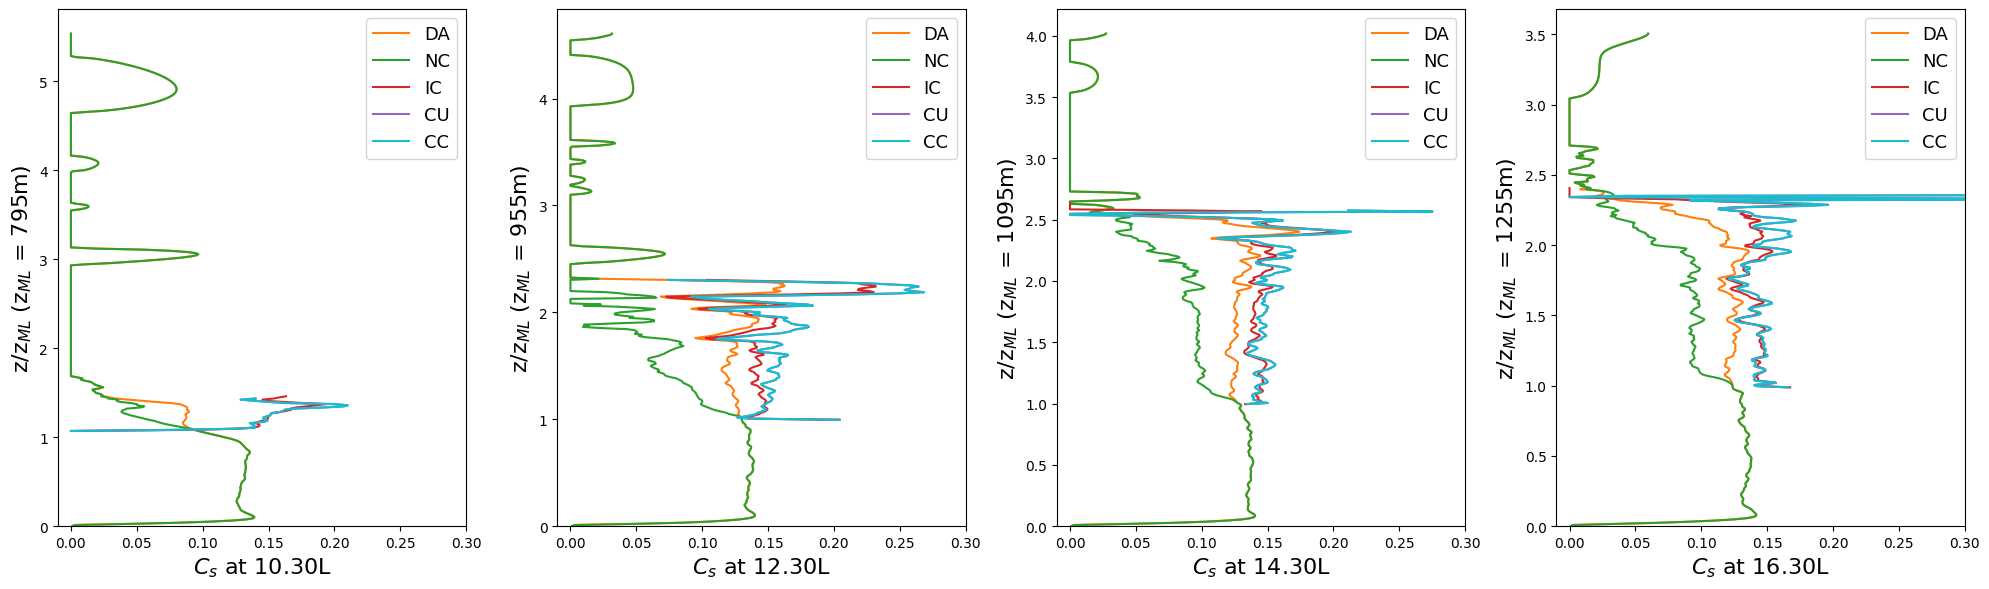

In [97]:
p_labels = ['DA', 'NC', 'IC', 'CU', 'CC']
d = 0

#Cs_sq_ARM_0[t,:,d,...], Cth_sq_ARM_0[t,:,d,...], Cth_L_sq_ARM_0[t,:,d,...], Cqt_sq_ARM_0[t,:,d,:],


plot_C_all_partit(Cs_sq_ARM_0[:,:,d,...], 'Cs', z_ARM, z_i_ARM, p_labels, plot_dir=plot_dir_ARM, case='ARM',
                   C_type = 'C', set_x_axis=[-0.01, 0.3], IC_label = False)

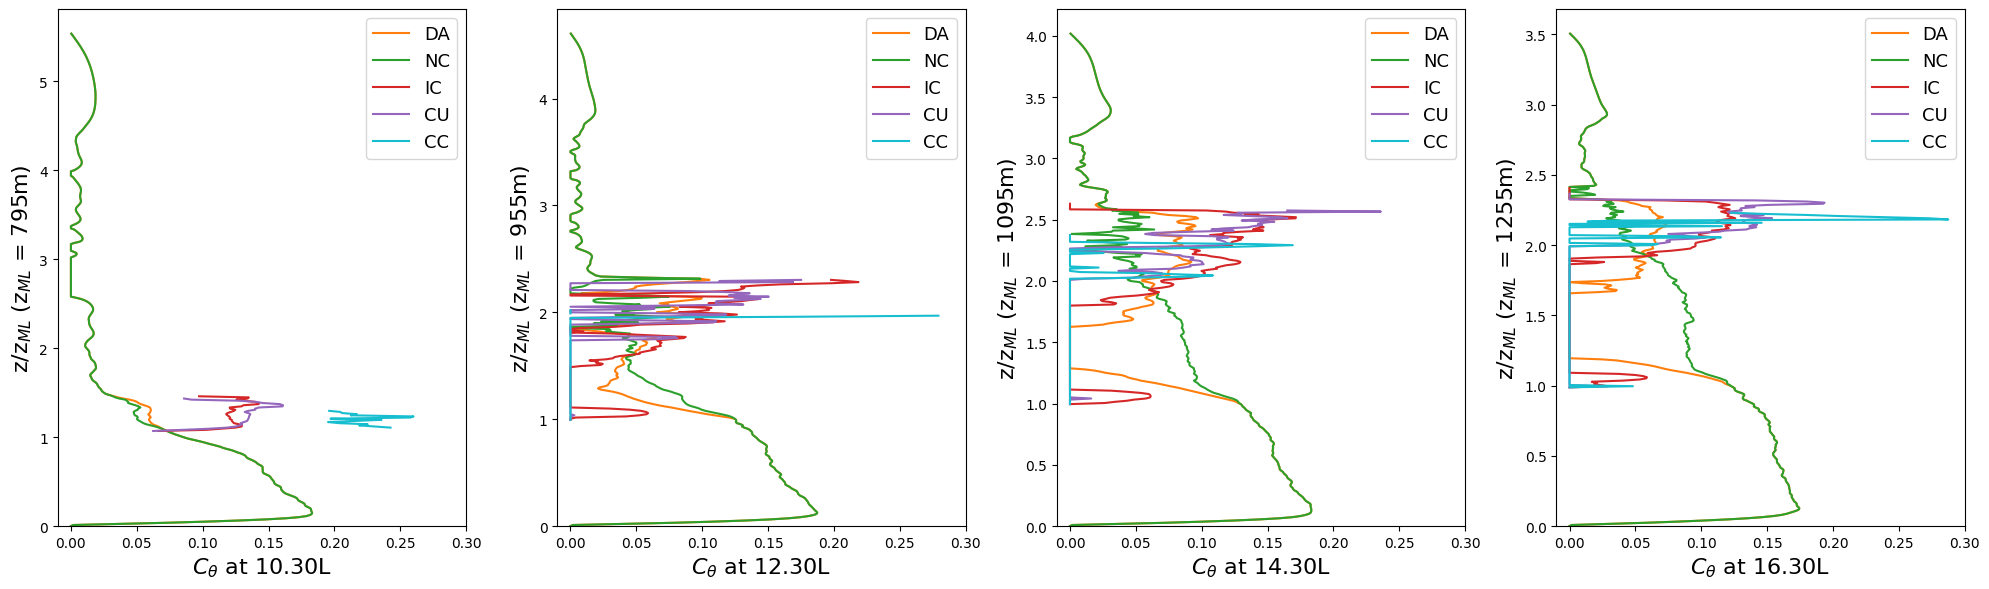

In [98]:
plot_C_all_partit(Cth_sq_ARM_0[:,:,d,...], 'Cth', z_ARM, z_i_ARM, p_labels, plot_dir=plot_dir_ARM, case='ARM',
                   C_type = 'C', set_x_axis=[-0.01, 0.3], IC_label = False)

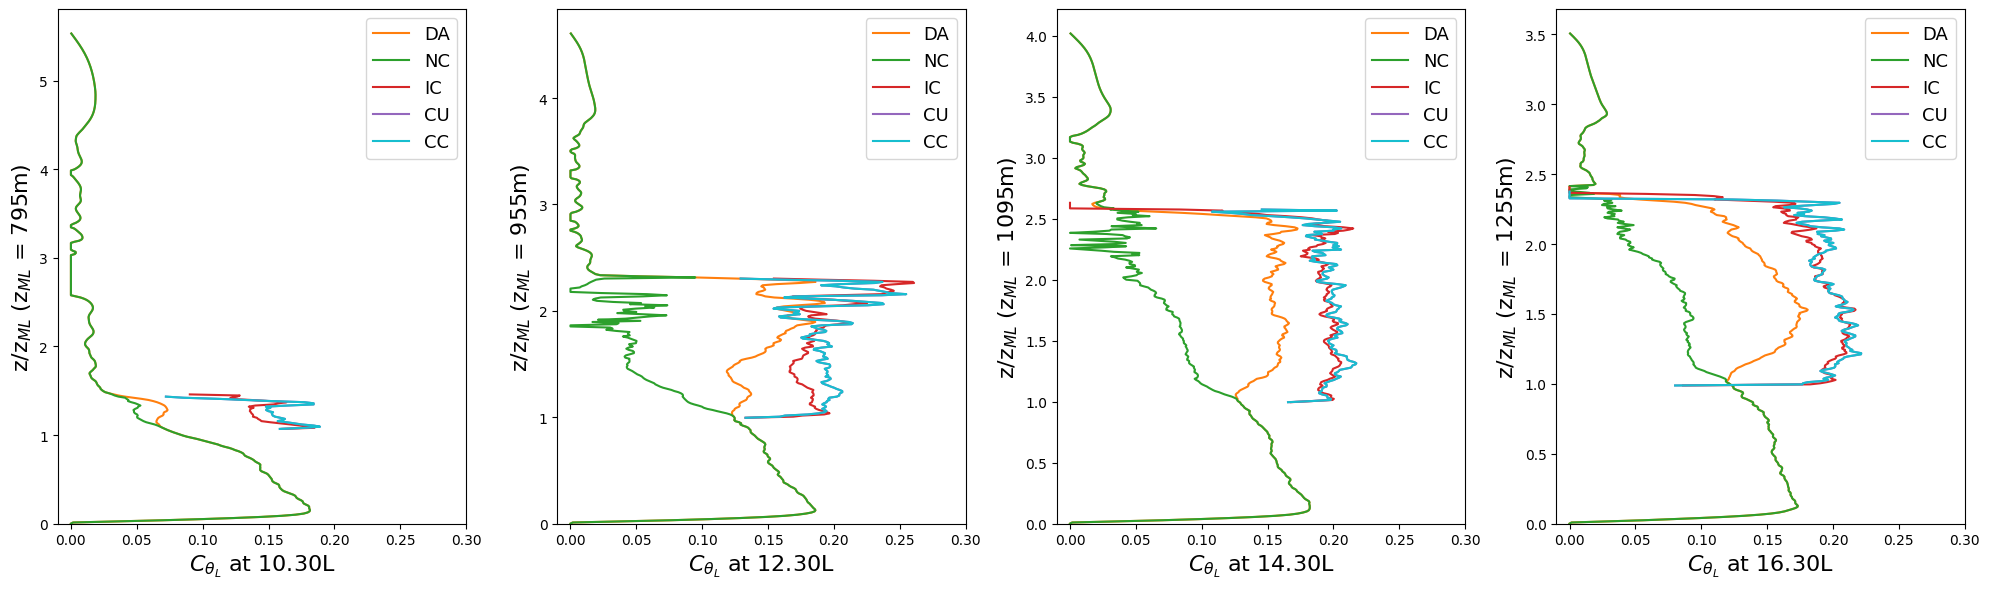

In [99]:
plot_C_all_partit(Cth_L_sq_ARM_0[:,:,d,...], 'Cth_L', z_ARM, z_i_ARM, p_labels, plot_dir=plot_dir_ARM, case='ARM',
                   C_type = 'C', set_x_axis=[-0.01, 0.3], IC_label = False)

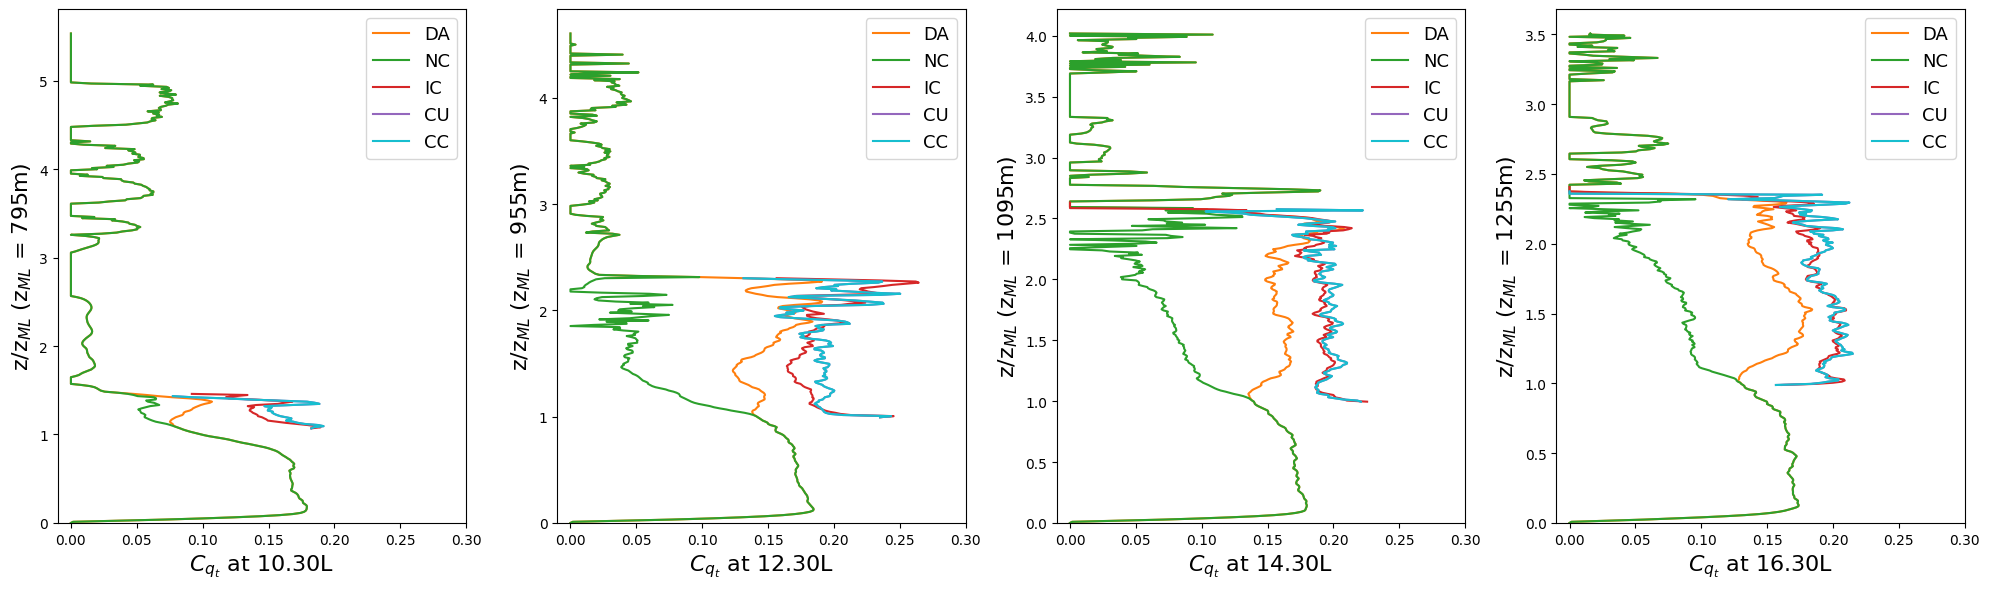

In [100]:
plot_C_all_partit(Cqt_sq_ARM_0[:,:,d,...], 'Cqt', z_ARM, z_i_ARM, p_labels, plot_dir=plot_dir_ARM, case='ARM',
                   C_type = 'C', set_x_axis=[-0.01, 0.3], IC_label = False)

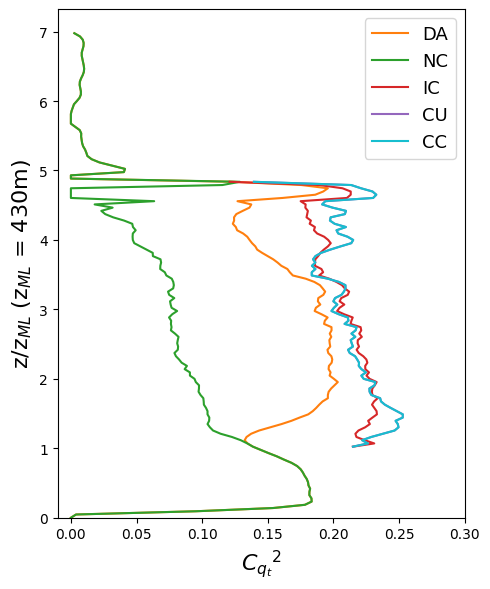

In [115]:
plot_C_all_partit(Cqt_sq_BOMEX_0[:,d,...], 'Cqt', z_BOMEX, z_i_BOMEX, p_labels, plot_dir=plot_dir_BOMEX, case='BOMEX',
                   C_type = 'C', set_x_axis=[-0.01, 0.3], IC_label = False)

In [116]:
qtp = 0
time_stamp = 0

plot_C_all_Deltas(C_sq_ARM_18000_0[0,p,...], C_sq_ARM_18000_0[1,p,...], C_sq_ARM_18000_0[2,p,...], C_sq_ARM_18000_1[:,p,:,:],
                  z_ARM, z_i_ARM[time_stamp], set_labels, 'domain average', plot_dir_ARM, case='ARM',
                  t=ARM_times[time_stamp], C_type = 'C', set_x_axis=[-0.01, 0.3], IC_label = False)

NameError: name 'C_sq_ARM_18000_0' is not defined

In [ ]:
p = 0

plot_C_all_Deltas(C_sq_BOMEX_0[0,p,...], C_sq_BOMEX_0[1,p,...], C_sq_BOMEX_0[2,p,...], C_sq_BOMEX_1[:,p,:,:],
                  z_BOMEX, z_i_BOMEX, set_labels, 'domain average', plot_dir_BOMEX, C_type = 'C_sq', IC_label=False)

In [ ]:
p = 1

plot_C_all_Deltas(C_sq_BOMEX_0[0,p,...], C_sq_BOMEX_0[1,p,...], C_sq_BOMEX_0[2,p,...], C_sq_BOMEX_1[:,p,:,:],
                  z_BOMEX, z_i_BOMEX, set_labels, 'NC', plot_dir_BOMEX)

In [ ]:
p = 2

plot_C_all_Deltas(C_sq_BOMEX_0[0,p,...], C_sq_BOMEX_0[1,p,...], C_sq_BOMEX_0[2,p,...], C_sq_BOMEX_1[:,p,:,:],
                  z_BOMEX, z_i_BOMEX, set_labels, 'IC', plot_dir_BOMEX, set_x_axis = [-0.01, 0.45])

In [ ]:
p = 2

plot_C_all_Deltas(C_sq_BOMEX_0[0,p,...], C_sq_BOMEX_0[1,p,...], C_sq_BOMEX_0[2,p,...], C_sq_BOMEX_1[:,p,:,:],
                  z_BOMEX, z_i_BOMEX, set_labels, 'IC', plot_dir_BOMEX, C_type = 'C_sq', IC_label=True, set_x_axis = [-0.01, 0.2])

In [ ]:
p = 3

plot_C_all_Deltas(C_sq_BOMEX_0[0,p,...], C_sq_BOMEX_0[1,p,...], C_sq_BOMEX_0[2,p,...], C_sq_BOMEX_1[:,p,:,:],
                  z_BOMEX, z_i_BOMEX, set_labels, 'CU', plot_dir_BOMEX, C_type = 'C_sq', set_x_axis = [-0.08, 0.1], IC_label=True)

In [ ]:
p = 3

plot_C_all_Deltas(C_sq_BOMEX_0[0,p,...], C_sq_BOMEX_0[1,p,...], C_sq_BOMEX_0[2,p,...], C_sq_BOMEX_1[:,p,:,:],
                  z_BOMEX, z_i_BOMEX, set_labels, 'CU', plot_dir_BOMEX, C_type = 'C', set_x_axis = [-0.01, 0.3], IC_label=True)

In [ ]:
p = 4

plot_C_all_Deltas(C_sq_BOMEX_0[0,p,...], C_sq_BOMEX_0[1,p,...], C_sq_BOMEX_0[2,p,...], C_sq_BOMEX_1[:,p,:,:],
                  z_BOMEX, z_i_BOMEX, set_labels, 'CC', plot_dir_BOMEX, C_type = 'C_sq', set_x_axis = [-0.08, 0.1], IC_label=True)

In [ ]:
p = 4

plot_C_all_Deltas(C_sq_BOMEX_0[0,p,...], C_sq_BOMEX_0[1,p,...], C_sq_BOMEX_0[2,p,...], C_sq_BOMEX_1[:,p,:,:],
                  z_BOMEX, z_i_BOMEX, set_labels, 'CC', plot_dir_BOMEX, C_type = 'C', set_x_axis = [-0.01, 0.35], IC_label=True)

In [ ]:
Pr = C_sq_BOMEX_0[0,...]/C_sq_BOMEX_0[1,...]
Sc = C_sq_BOMEX_0[0,...]/C_sq_BOMEX_0[2,...]

print(np.shape(Pr))

In [ ]:
# Pr[Pr > 2.95] = np.nan
# Pr[Pr < -0.45] = np.nan
#
# Sc[Sc > 2.95] = np.nan
# Sc[Sc < -0.45] = np.nan
#
# Pr = ma.masked_invalid(Pr)
# Sc = ma.masked_invalid(Sc)

In [ ]:
p = 0
d = 0

Pr_set = Pr[p, d,...]
Sc_set = Sc[p, d,...]

plt.figure(figsize=(4, 6))
plt.plot(Pr_set, z_BOMEX / z_i_BOMEX, label='$Pr$')
plt.plot(Sc_set, z_BOMEX / z_i_BOMEX, label='$Sc_{qt}$')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('$Pr$ and $Sc_{qt}$' + f' domain averages at {set_labels[d]}', size=14)
plt.ylabel('Height scaled by CBL inversion height', size=14)
bottom0, top0 = plt.ylim()

plt.xlim(0, 1.5)

plt.axvline(0.7, bottom0, top0, color='k', linestyle='dashed')

plt.ylim(0, 6)

plt.savefig(f'{plot_dir_BOMEX}BOMEX_Pr_Sc_{partit[p]}_{deltas[d]}.pdf', bbox_inches='tight')

In [ ]:
p = 1
d = 0

Pr_set = Pr[p, d,...]
Sc_set = Sc[p, d,...]

plt.figure(figsize=(4, 6))
plt.plot(Pr_set, z_BOMEX / z_i_BOMEX, label='$Pr$')
plt.plot(Sc_set, z_BOMEX / z_i_BOMEX, label='$Sc_{qt}$')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('$Pr$ and $Sc_{qt}$' + f' {partit[p]} averages at {set_labels[d]}', size=14)
plt.ylabel('Height scaled by CBL inversion height', size=14)
bottom0, top0 = plt.ylim()

plt.xlim(0, 3)

plt.axvline(0.7, bottom0, top0, color='k', linestyle='dashed')

plt.ylim(0, 6)

plt.savefig(f'{plot_dir_BOMEX}BOMEX_Pr_Sc_{partit[p]}_{deltas[d]}.png', bbox_inches='tight')

In [ ]:
p = 4
d = 0

Pr_set = Pr[p, d, ...]
Sc_set = Sc[p, d, ...]

plt.figure(figsize=(4, 6))
plt.plot(Pr_set, z_BOMEX / z_i_BOMEX, label='$Pr$')
plt.plot(Sc_set, z_BOMEX / z_i_BOMEX, label='$Sc_{qt}$')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('$Pr$ and $Sc_{qt}$' + f' {partit[p]} averages at {set_labels[d]}', size=14)
plt.ylabel('Height scaled by CBL inversion height', size=14)
bottom0, top0 = plt.ylim()

plt.xlim(0, 1.5)

plt.axvline(0.7, 0, top0, color='k', linestyle='dashed')

plt.ylim(0, 6)

plt.savefig(f'{plot_dir_BOMEX}BOMEX_Pr_Sc_{partit[p]}_{deltas[d]}.png', bbox_inches='tight')

In [ ]:
Cs_sq = np.load(path+f'Cs_sq_cond_32400.npy')[0]
np.shape(Cs_sq)

In [ ]:
plt.figure(figsize=(4,6))
plt.plot(get_Cs(Cs_sq)[1,:], z/z_i, label='$\\Delta = 50m$')
plt.plot(get_Cs(Cs_sq)[2,:], z/z_i, label='$\\Delta = 100m$')
plt.plot(sc.savgol_filter(get_Cs(Cs_sq)[3,:], 21, 3), z/z_i, label='$\\Delta = 200m$')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('$C_s$ value', size=14)
plt.ylabel('Height scaled by CBL inversion height', size=14)
plt.savefig('ARM_C_50_100_200.pdf', bbox_inches='tight')

In [ ]:
def l_mix_MONC(Delta, Cs, z_in, k=0.4):
    l_mix = np.sqrt(1 / ((1 / (Cs * Cs * Delta * Delta)) + (1 / (k * k * z_in * z_in))))

    return l_mix

In [ ]:
plt.figure(figsize=(4,6))
plt.plot(50*get_Cs(Cs_sq)[1,:], z/z_i, '--', label='$\\Delta = 50m$')
plt.plot(100*get_Cs(Cs_sq)[2,:], z/z_i, '--', label='$\\Delta = 100m$')
plt.plot(sc.savgol_filter(200*get_Cs(Cs_sq)[3,:], 51, 3), z/z_i, '--', label='$\\Delta = 200m$')
plt.plot(l_mix_MONC(50, 0.23, z), z/z_i, color='tab:blue')
plt.plot(l_mix_MONC(100, 0.23, z), z/z_i, color='tab:orange')
plt.plot(l_mix_MONC(200, 0.23, z), z/z_i, color='tab:green')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('Mixing length for momentum', size=14)
plt.ylabel('Height scaled by CBL inversion height', size=14)
plt.savefig('ARM_lmix_50_100_200.pdf', bbox_inches='tight')

In [101]:
def cal_mean_Cs(C_list, C_beta, z_ml_r, z_cl_r):

    print('when calc the mean values, shape of C list is ', np.shape(C_list))

    mean_C = np.zeros((6,7))

    for i in range(np.shape(C_list)[0]):
        for nD in range(7):
            if nD == 0:
                if i == 0:
                    mean_C[i, nD] = np.mean(C_beta[i, int(z_ml_r[0]):int(z_ml_r[1])])
                    mean_C[i+1, nD] = np.mean(C_beta[i, int(z_cl_r[0]):int(z_cl_r[1])])
                else:
                    mean_C[i+1, nD] = np.mean(C_beta[i, int(z_cl_r[0]):int(z_cl_r[1])])

            else:
                if i == 0:
                    mean_C[i, nD] = np.mean(C_list[i, nD-1, int(z_ml_r[0]):int(z_ml_r[1])])
                    mean_C[i+1, nD] = np.mean(C_list[i, nD-1, int(z_cl_r[0]):int(z_cl_r[1])])
                else:
                    mean_C[i+1, nD] = np.mean(C_list[i, nD-1, int(z_cl_r[0]):int(z_cl_r[1])])

    print('shape of mean C is ', np.shape(mean_C))
    return mean_C

In [117]:
BOMEX_ML_range = np.array([100, 400])
BOMEX_CL_range = np.array([500, 1500])

ARM_ML_range = np.array([ [100, 700], [100, 900], [100, 1000], [100, 1000] ])
ARM_CL_range = np.array([ [900, 1050], [1100, 1400], [1250, 1850], [1400, 2150] ])

BOMEX_ML_ind = BOMEX_ML_range/20
BOMEX_CL_ind = BOMEX_CL_range/20
ARM_ML_ind = ARM_ML_range/10
ARM_CL_ind = ARM_CL_range/10


In [118]:
C_sq_all_ARM_0 = [Cs_sq_ARM_0, Cth_sq_ARM_0, Cth_L_sq_ARM_0, Cqt_sq_ARM_0]
C_sq_all_BOMEX_0 = [Cs_sq_BOMEX_0, Cth_sq_BOMEX_0, Cth_L_sq_BOMEX_0, Cqt_sq_BOMEX_0]


Cs_sq_ARM_beta = Cs_sq_ARM_0[:,:,0,...]/(Cs_sq_ARM_1[:,:,0,...]/Cs_sq_ARM_0[:,:,0,...])
Cth_sq_ARM_beta = Cth_sq_ARM_0[:,:,0,...]/(Cth_sq_ARM_1[:,:,0,...]/Cth_sq_ARM_0[:,:,0,...])
Cth_L_sq_ARM_beta = Cth_L_sq_ARM_0[:,:,0,...]/(Cth_L_sq_ARM_1[:,:,0,...]/Cth_L_sq_ARM_0[:,:,0,...])
Cqt_sq_ARM_beta = Cqt_sq_ARM_0[:,:,0,...]/(Cqt_sq_ARM_1[:,:,0,...]/Cqt_sq_ARM_0[:,:,0,...])

C_sq_all_ARM_beta = [Cs_sq_ARM_beta, Cth_sq_ARM_beta, Cth_L_sq_ARM_beta, Cqt_sq_ARM_beta]



Cs_sq_BOMEX_beta = Cs_sq_BOMEX_0[:,0,...]/(Cs_sq_BOMEX_1[:,0,...]/Cs_sq_BOMEX_0[:,0,...])
Cth_sq_BOMEX_beta = Cth_sq_BOMEX_0[:,0,...]/(Cth_sq_BOMEX_1[:,0,...]/Cth_sq_BOMEX_0[:,0,...])
Cth_L_sq_BOMEX_beta = Cth_L_sq_BOMEX_0[:,0,...]/(Cth_L_sq_BOMEX_1[:,0,...]/Cth_L_sq_BOMEX_0[:,0,...])
Cqt_sq_BOMEX_beta = Cqt_sq_BOMEX_0[:,0,...]/(Cqt_sq_BOMEX_1[:,0,...]/Cqt_sq_BOMEX_0[:,0,...])

C_sq_all_BOMEX_beta = [Cs_sq_BOMEX_beta, Cth_sq_BOMEX_beta, Cth_L_sq_BOMEX_beta, Cqt_sq_BOMEX_beta]

In [104]:
#print(np.shape(C_sq_all_BOMEX_beta[0][2, BOMEX_ML_ind[0]:BOMEX_ML_ind[1]]))

print(BOMEX_ML_ind[0])

5.0


In [105]:
set_labels_w_b = ['2$\\Delta$', '4$\\Delta$', '8$\\Delta$', '16$\\Delta$', '32$\\Delta$', '64$\\Delta$', '128$\\Delta$']
deltas_w_b = ['2D', '4D', '8D', '16D', '32D', '64D', '128D']

In [119]:
BOMEX_C_max = np.zeros((4,6,7)) #var,p,D
ARM_C_max = np.zeros((4,4,6,7)) #var,t,p,D

for var in range(4):
    BOMEX_C_max[var, ...] = cal_mean_Cs(C_sq_all_BOMEX_0[var][...], C_sq_all_BOMEX_beta[var][...], BOMEX_ML_ind, BOMEX_CL_ind)
    for t in range(4):
        ARM_C_max[var, t, ...] = cal_mean_Cs(C_sq_all_ARM_0[var][t, ...], C_sq_all_ARM_beta[var][t, ...], ARM_ML_ind[t,...], ARM_CL_ind[t,...])

when calc the mean values, shape of C list is  (5, 6, 151)
shape of mean C is  (6, 7)
when calc the mean values, shape of C list is  (5, 6, 441)
shape of mean C is  (6, 7)
when calc the mean values, shape of C list is  (5, 6, 441)
shape of mean C is  (6, 7)
when calc the mean values, shape of C list is  (5, 6, 441)
shape of mean C is  (6, 7)
when calc the mean values, shape of C list is  (5, 6, 441)
shape of mean C is  (6, 7)
when calc the mean values, shape of C list is  (5, 6, 151)
shape of mean C is  (6, 7)
when calc the mean values, shape of C list is  (5, 6, 441)
shape of mean C is  (6, 7)
when calc the mean values, shape of C list is  (5, 6, 441)
shape of mean C is  (6, 7)
when calc the mean values, shape of C list is  (5, 6, 441)
shape of mean C is  (6, 7)
when calc the mean values, shape of C list is  (5, 6, 441)
shape of mean C is  (6, 7)
when calc the mean values, shape of C list is  (5, 6, 151)
shape of mean C is  (6, 7)
when calc the mean values, shape of C list is  (5, 6, 

In [107]:
print(BOMEX_C_max[0, ...])

[[ 3.27686583e-02  1.76427267e-02  9.73861423e-03  5.39075613e-03
   3.72450702e-03  1.12092444e-03  5.88837924e-05]
 [ 5.16203001e-02  1.46781998e-02  2.54756974e-03 -9.41121737e-04
  -1.85827941e-04 -4.10342066e-05 -2.84973963e-07]
 [ 2.21190984e-02  8.28730447e-03  1.22973653e-03 -9.49663451e-04
  -5.07798754e-04 -6.09289155e-05  5.94996847e-07]
 [ 4.24467334e-02  1.84374383e-02  4.11713923e-03 -6.78530504e-04
   7.81731573e-04             nan             nan]
 [ 9.43506913e-02  1.80612990e-02  8.79111590e-04 -1.21414902e-02
              nan             nan             nan]
 [ 9.43506913e-02  1.80612990e-02  8.79111590e-04 -1.21414902e-02
              nan             nan             nan]]


In [108]:
def get_max_l_from_C(max_C_cond, deltas_num, grid_spacing):
    Delta_res = deltas_num*grid_spacing
    max_l_cond = np.zeros_like(max_C_cond)
    for it in range(np.shape(max_C_cond)[1]):
        max_l_cond[:,it] = max_C_cond[:,it] * Delta_res[it]
    print('shape of max l is ', np.shape(max_l_cond))
    return max_l_cond

D_labels = ['2$\\Delta$', '4$\\Delta$', '8$\\Delta$', '16$\\Delta$', '32$\\Delta$', '64$\\Delta$', '128$\\Delta$']


def plot_max_C_l_vs_Delta(Cs_max_in, Cth_max_in, Cth_L_max_in, Cqt_max_in, case, time, Delta, plotdir, y_ax='C', max_mean='max'):

    my_lines = ['solid', 'solid', 'dotted', 'dashed', 'dashed', 'dashed']
    #labels = ['ML domain', 'CL domain', 'CL: clear sky', 'in-cloud', 'cloudy updraft', 'cloud core']
    labels = ['ML', 'CL', 'NC', 'IC', 'CU', 'CC']

    colours = ['k', 'tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple',
               'tab:cyan', 'tab:gray', 'tab:brown', 'tab:olive', 'tab:pink']

    if y_ax == 'C':
        y_labels = ['$C_{s}$', '$C_{\\theta}$', '$C_{\\theta_L}$', '$C_{qt}$']
    elif y_ax == 'l':
        y_labels = ['$l_{s}$ (m)', '$l_{\\theta}$ (m)', '$l_{\\theta_L}$ (m)', '$l_{qt}$ (m)']
    elif y_ax == 'Pr':
        y_labels = ['$Pr_\\theta$', '$Pr_{\\theta_L}$', '$Sc_{qt}$']
    else:
        print('y_ax input not recognised')

    if y_ax == 'Pr':
        if case=='BOMEX':
            fig, ax = plt.subplots(nrows=1, ncols=3, sharey=False, figsize=(15, 5))
        else:
            fig, ax = plt.subplots(nrows=3, ncols=1, sharey=False, figsize=(5, 15))
    else:
        if case=='BOMEX':
            fig, ax = plt.subplots(nrows=1, ncols=4, sharey=False, figsize=(20, 5))
        else:
            fig, ax = plt.subplots(nrows=4, ncols=1, sharey=False, figsize=(5, 18))
    fig.tight_layout(pad=0.5)

    for it in range(np.shape(Cs_max_in)[0]):
        ax[0].semilogx(Delta, Cs_max_in[it,...], color=colours[it], linestyle=my_lines[it], label=labels[it])
        ax[1].semilogx(Delta, Cth_max_in[it,...], color=colours[it], linestyle=my_lines[it], label=labels[it])
        ax[2].semilogx(Delta, Cth_L_max_in[it, ...], color=colours[it], linestyle=my_lines[it], label=labels[it])
        if y_ax != 'Pr':
            ax[3].semilogx(Delta, Cqt_max_in[it,...], color=colours[it], linestyle=my_lines[it], label=labels[it])

    if y_ax == 'C':
        ax[0].legend(fontsize=13, loc='upper right')
        ax[1].legend(fontsize=13, loc='upper right')
        ax[2].legend(fontsize=13, loc='upper right')
        ax[3].legend(fontsize=13, loc='upper right')
    elif y_ax == 'l':
        ax[0].legend(fontsize=13, loc='best')
        ax[1].legend(fontsize=13, loc='best')
        ax[2].legend(fontsize=13, loc='best')
        ax[3].legend(fontsize=13, loc='best')
    elif y_ax == 'Pr':
        ax[0].legend(fontsize=13, loc='upper right')
        ax[1].legend(fontsize=13, loc='upper right')
        ax[2].legend(fontsize=13, loc='upper right')

    bottom0, top0 = ax[0].set_ylim()
    bottom1, top1 = ax[1].set_ylim()
    bottom2, top2 = ax[2].set_ylim()
    if y_ax != 'Pr':
        bottom3, top3 = ax[3].set_ylim()

    if max_mean == 'mean':
        set_top = max(top0, top1, top2)
        if y_ax != 'Pr':
            temp_top = set_top
            set_top = max(temp_top, top3)  # 0.255

    elif max_mean == 'max':
        set_top = max(top0, top1, top2)
        if y_ax != 'Pr':
            temp_top = set_top
            set_top = max(temp_top, top3)  # 0.305

    ax[0].set_ylim(top=set_top)
    ax[1].set_ylim(top=set_top)
    ax[2].set_ylim(top=set_top)
    if y_ax != 'Pr':
        ax[3].set_ylim(top=set_top)

    for it in range(len(y_labels)):
        ax[it].set_ylabel(y_labels[it], fontsize=16)
        ax[it].set_xlabel('Filter scale $\\widehat{\\bar{\\Delta}}$', fontsize=16)
        ax[it].set_xticks(Delta, D_labels)

    # ax[0].set_title(y_labels[0], fontsize=16)
    # ax[1].set_title(y_labels[1], fontsize=16)
    # ax[2].set_title(y_labels[2], fontsize=16)

    plt.tight_layout()

    plt.savefig(plotdir+f'{case}_{time}_{max_mean}_{y_ax}_vs_Delta.pdf', bbox_inches='tight')
    plt.show()
    plt.close()


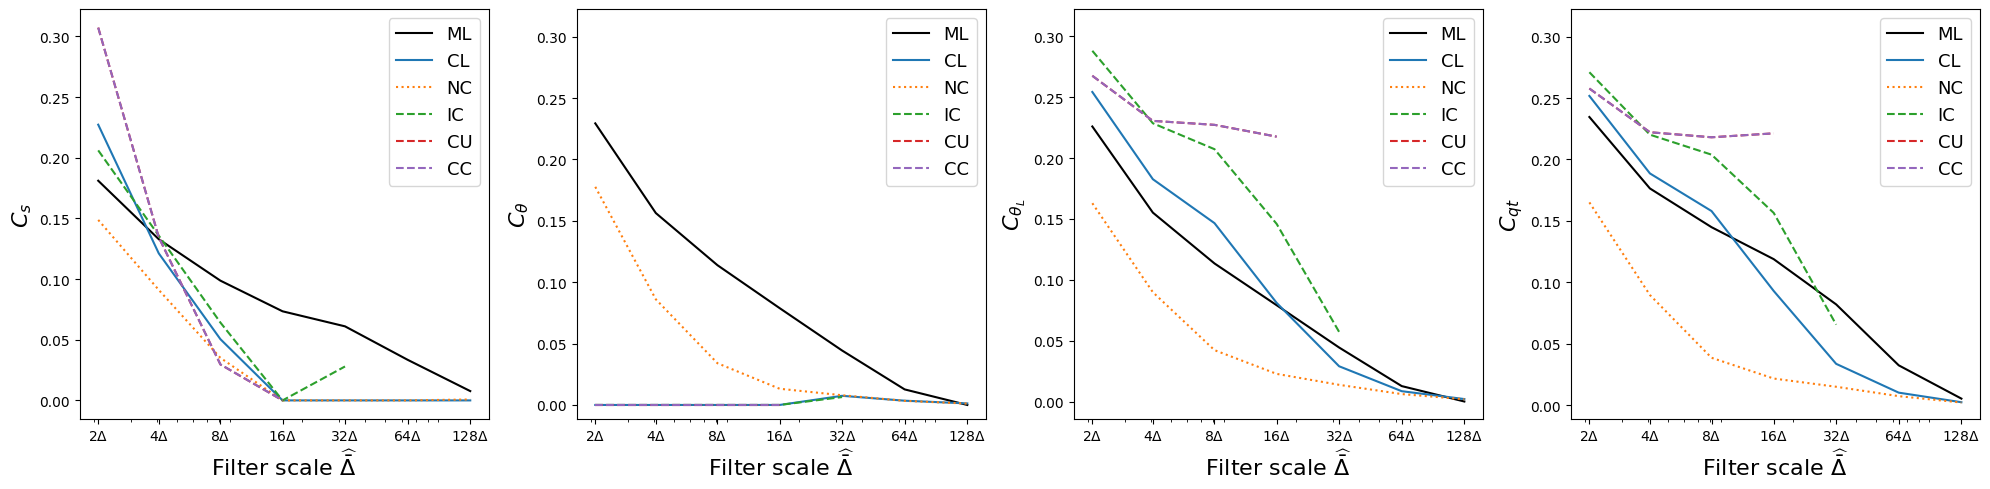

In [109]:
# BOMEX_C_max ARM_C_max

plot_max_C_l_vs_Delta(get_Cs(BOMEX_C_max[0,...]), get_Cs(BOMEX_C_max[1,...]), get_Cs(BOMEX_C_max[2,...]), get_Cs(BOMEX_C_max[3,...]), 'BOMEX', '14400', D_m_BOMEX, plot_dir_BOMEX, y_ax='C', max_mean='max')

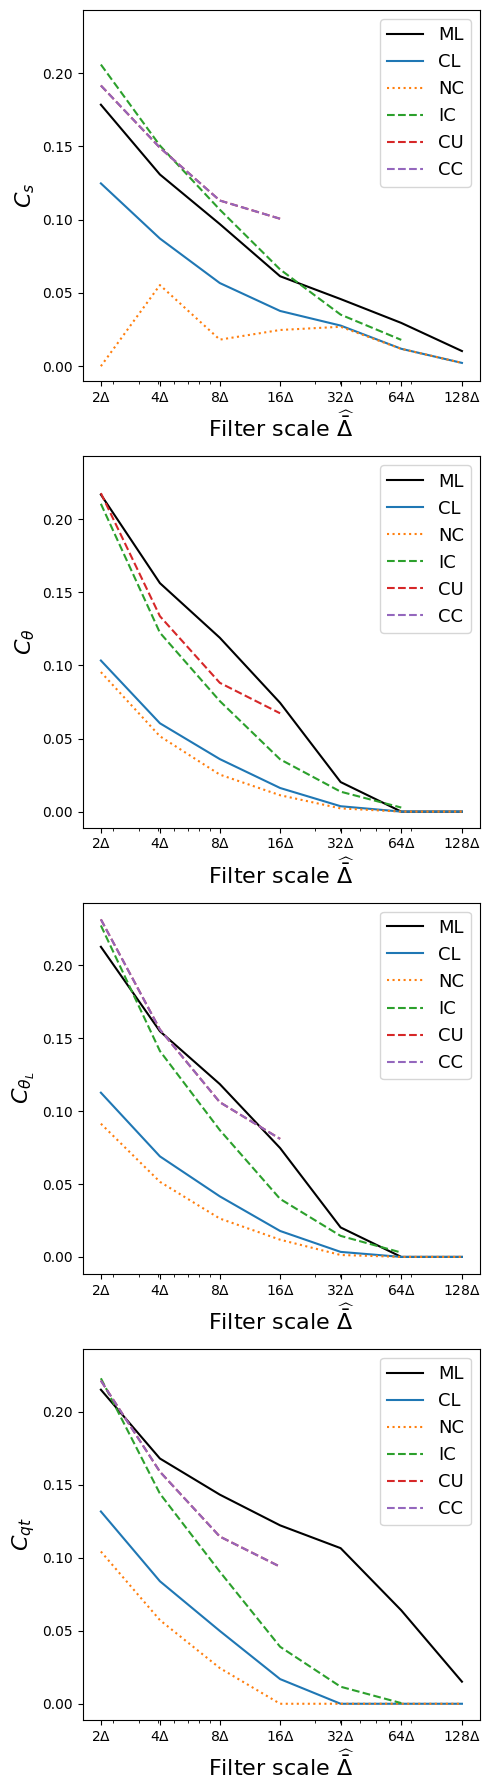

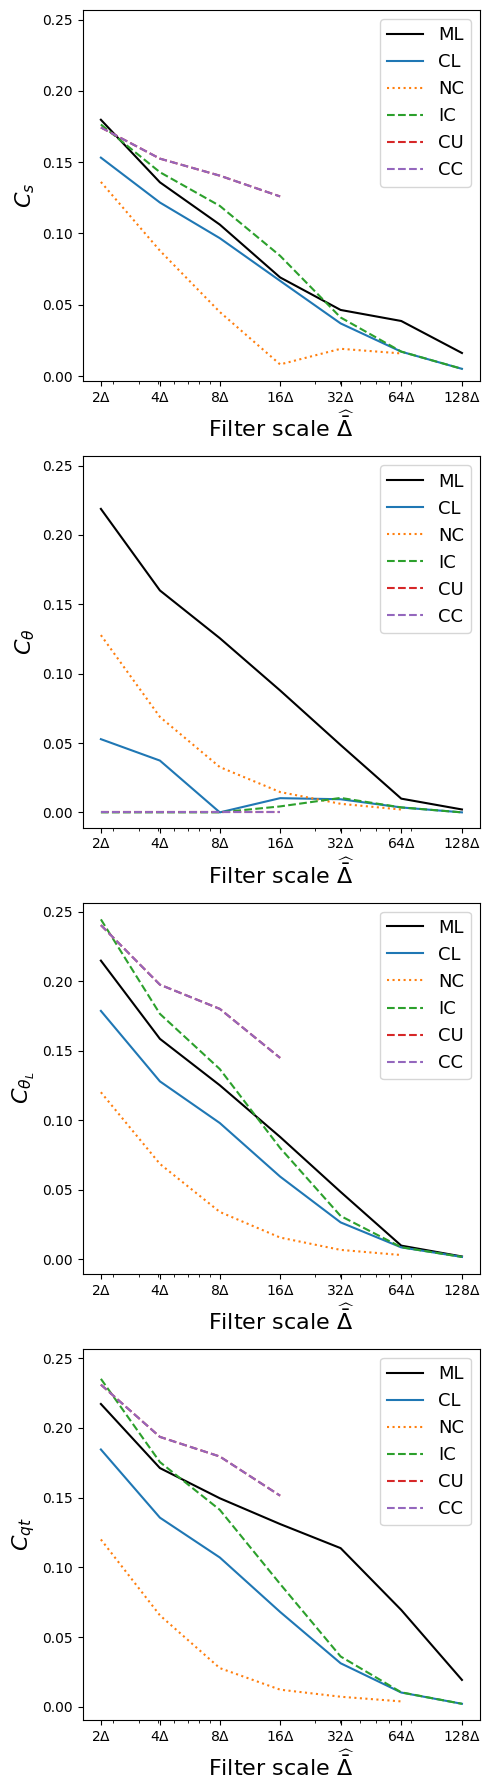

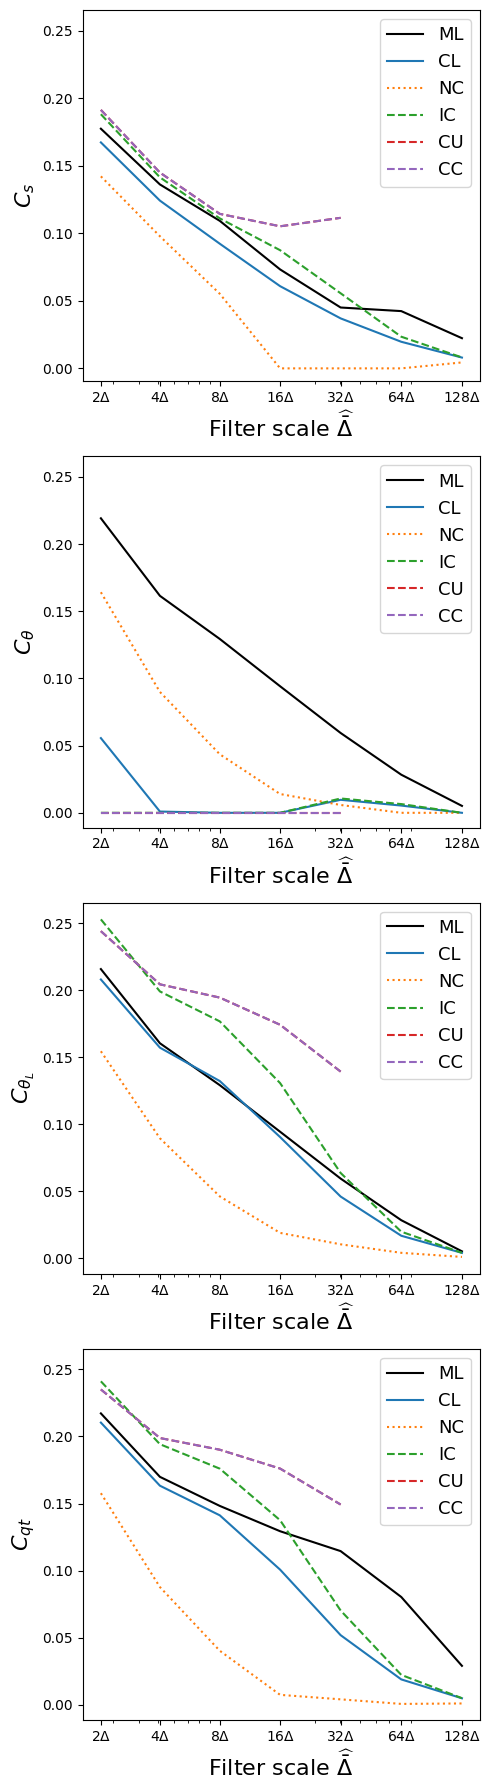

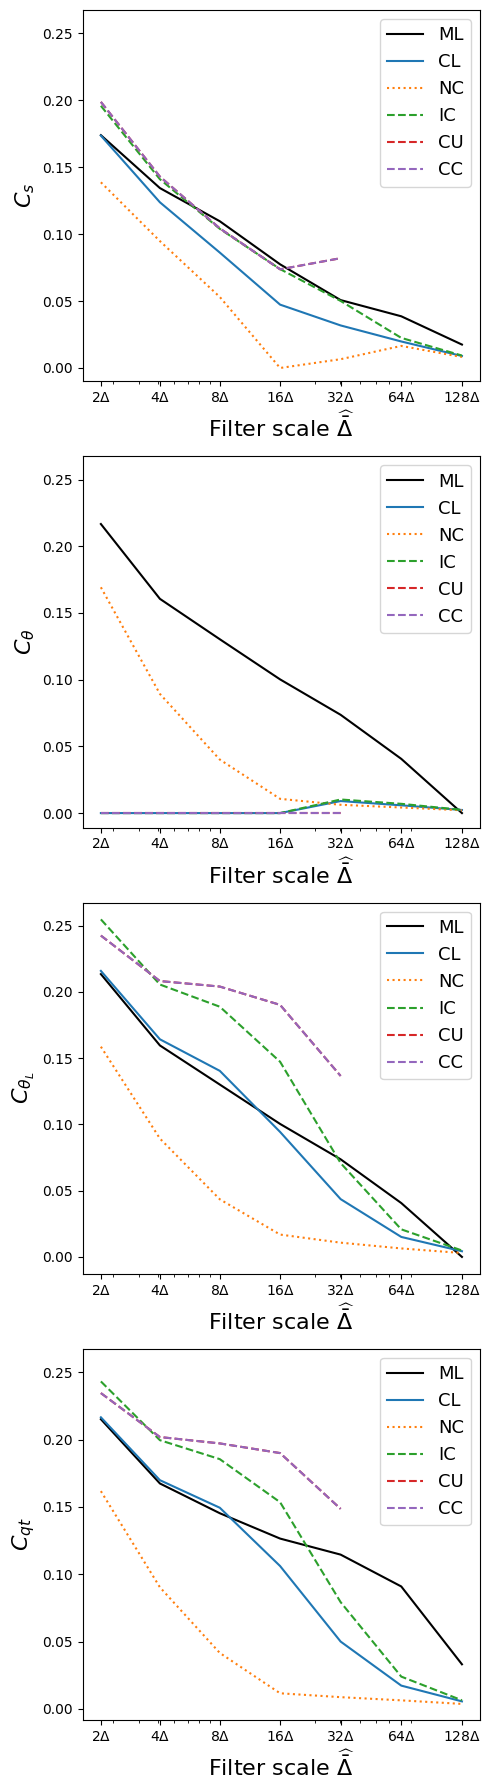

In [120]:
for nt in range(4):
    plot_max_C_l_vs_Delta(get_Cs(ARM_C_max[0, nt,...]), get_Cs(ARM_C_max[1, nt,...]), get_Cs(ARM_C_max[2, nt,...]), get_Cs(ARM_C_max[3, nt,...]), 'ARM', ARM_times[nt], D_m_ARM, plot_dir_ARM, y_ax='C', max_mean='max')